# Algorithmic Trading Group Project
# Full Pipeline: Data → Strategy → Backtest → Paper Trade

---

## What This Notebook Does

This notebook builds a **complete algorithmic trading system** from scratch. We will:

1. **Collect stock data** for a portfolio of multiple assets
2. **Explore the data** to understand what we're working with
3. **Build Benchmark Strategies:**
   - Buy-and-Hold S&P 500 (simplest possible strategy)
   - Mean-Variance Optimization (classic portfolio theory)
4. **Build Main Strategies:**
   - **Path A:** Reinforcement Learning with FinRL (a robot that learns to trade)
   - **Path B:** LLM-based Trading Signals (asking AI like ChatGPT/Claude for trading decisions)
5. **Backtest** all strategies on historical data
6. **Paper trade** on Alpaca (real-time trading with fake money)
7. **Compare** everything and draw conclusions

### Prerequisites
- Basic Python knowledge
- No prior trading or finance knowledge required — everything is explained!

---
# Section 1: Setup & Installation

First, we need to install all the Python packages (libraries) we'll use.

Think of packages as **toolboxes** — someone already built the tools, we just use them.

| Package | What it does |
|---|---|
| `yfinance` | Downloads stock price data from Yahoo Finance (free) |
| `pandas` | Works with data in tables (like Excel but in Python) |
| `numpy` | Does math operations fast |
| `matplotlib` / `seaborn` | Creates charts and graphs |
| `scipy` | Advanced math (we use it for portfolio optimization) |
| `vectorbt` | Backtesting engine — simulates trading on historical data |
| `finrl` | Reinforcement learning for trading (Path A) |
| `openai` | Talks to LLM APIs like GPT/Claude (Path B) |
| `alpaca-py` | Connects to Alpaca for paper trading |

In [1]:
# Run this cell to install all required packages
# The '!' means "run this as a terminal command" (not Python code)
# '-q' means quiet mode (less output)

!pip install -q yfinance pandas numpy matplotlib seaborn scipy
!pip install -q vectorbt
!pip install -q finrl stockstats exchange_calendars wrds
!pip install -q openai
!pip install -q alpaca-py
# Technical analysis indicators (RSI, MACD, etc.)
!pip install -q ta

In [2]:
# Now we IMPORT the packages — this loads them into memory so we can use them

import yfinance as yf           # 'as yf' means we can type yf instead of yfinance
import pandas as pd             # pd is the standard shorthand for pandas
import numpy as np              # np is the standard shorthand for numpy
import matplotlib.pyplot as plt # plt is standard for matplotlib
import seaborn as sns           # sns is standard for seaborn
from scipy.optimize import minimize  # One specific function from scipy
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')  # Hide warning messages to keep output clean

# Set plot style so our charts look nice
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 7)  # Default chart size
plt.rcParams['font.size'] = 12

print('All packages loaded successfully!')

All packages loaded successfully!


---
# Section 2: Data Collection

## What Are We Downloading?

We need **historical stock prices** — the daily open, high, low, close prices and volume for each stock.

**Key terms:**
- **Open**: Price when the market opens at 9:30 AM
- **High**: Highest price reached during the day
- **Low**: Lowest price reached during the day
- **Close**: Price when the market closes at 4:00 PM (this is the most important one)
- **Volume**: How many shares were traded that day (higher = more activity)
- **Adj Close**: Close price adjusted for dividends and stock splits (we use this for calculations)

## Which Stocks?

We'll pick **15 well-known stocks** from different sectors. Diversification (picking stocks from different industries) is important because if tech stocks crash, healthcare stocks might still be fine.

We also download **SPY** (an ETF that tracks the S&P 500 index) as our benchmark.

In [3]:
# Define our stock universe
# Each "ticker" is a stock's short code (like a nickname)

TICKERS = [
    'AAPL',   # Apple — Technology
    'MSFT',   # Microsoft — Technology
    'GOOGL',  # Google/Alphabet — Technology
    'AMZN',   # Amazon — Consumer/Tech
    'NVDA',   # NVIDIA — Semiconductors
    'JPM',    # JPMorgan Chase — Banking
    'JNJ',    # Johnson & Johnson — Healthcare
    'V',      # Visa — Financial Services
    'PG',     # Procter & Gamble — Consumer Goods
    'XOM',    # ExxonMobil — Energy
    'UNH',    # UnitedHealth — Healthcare
    'HD',     # Home Depot — Retail
    'DIS',    # Disney — Entertainment
    'KO',     # Coca-Cola — Consumer Goods
    'PFE',    # Pfizer — Pharmaceuticals
]

BENCHMARK = 'SPY'  # S&P 500 ETF — our benchmark to beat

# Time period for our data
# We use 5 years of data:
#   - First 4 years (2020-2023) for training/backtesting
#   - Last year (2024-2025) for out-of-sample testing
START_DATE = '2020-01-01'
END_DATE = '2025-12-31'

# Starting capital for our portfolio (how much fake money we begin with)
INITIAL_CAPITAL = 1_000_000  # $1,000,000

print(f'Stock universe: {len(TICKERS)} stocks')
print(f'Period: {START_DATE} to {END_DATE}')
print(f'Starting capital: ${INITIAL_CAPITAL:,.0f}')

Stock universe: 15 stocks
Period: 2020-01-01 to 2025-12-31
Starting capital: $1,000,000


In [4]:
# Download stock data from Yahoo Finance
# This is FREE and doesn't require any API key

print('Downloading stock data... (this may take a minute)')

# Download all tickers + benchmark in one call
all_tickers = TICKERS + [BENCHMARK]
raw_data = yf.download(all_tickers, start=START_DATE, end=END_DATE, auto_adjust=False)

print(f'\nDownloaded data shape: {raw_data.shape}')
print(f'Date range: {raw_data.index[0].date()} to {raw_data.index[-1].date()}')
print(f'Total trading days: {len(raw_data)}')

[*********************100%***********************]  16 of 16 completed


Downloaded data shape: (1507, 96)
Date range: 2020-01-02 to 2025-12-30
Total trading days: 1507


In [5]:
# Extract the Adjusted Close prices — this is what we use for calculations
# "Adjusted" means it accounts for stock splits and dividends
#
# Example: If a stock was $100, then did a 2-for-1 split, the price drops to $50
# but you now own 2x shares. Adjusted close fixes this so the chart looks smooth.

prices = raw_data['Adj Close'].dropna(how='all')  # Only drop rows where ALL tickers are missing
# Forward-fill small gaps (e.g., one ticker missing a single day)
prices = prices.ffill()

# Separate our stocks from the benchmark
stock_prices = prices[TICKERS]
benchmark_prices = prices[BENCHMARK]

# Free memory — we no longer need the full raw OHLCV data
del raw_data

print('Price data sample (first 5 rows):')
stock_prices.head()

Price data sample (first 5 rows):


Ticker,AAPL,MSFT,GOOGL,AMZN,NVDA,JPM,JNJ,V,PG,XOM,UNH,HD,DIS,KO,PFE
Date,,,,,,,,,,,,,,,
2020-01-02,72.400528,152.158371,67.873032,94.900497,5.970755,119.036400,122.638237,182.809265,105.524002,53.306408,263.196838,188.727631,144.790253,45.432709,27.494839
2020-01-03,71.696648,150.263763,67.517960,93.748497,5.875187,117.465546,121.218353,181.355362,104.814316,52.877846,260.533417,188.100433,143.129379,45.184845,27.347322
2020-01-06,72.267906,150.652191,69.317589,95.143997,5.899825,117.372162,121.067131,180.963181,104.959679,53.283859,262.342041,188.985413,142.298935,45.168324,27.312197
2020-01-07,71.928047,149.278595,69.183693,95.343002,5.971252,115.376740,121.806473,180.484940,104.309814,52.847775,260.758362,187.748154,142.347778,44.821323,27.220881
2020-01-08,73.085121,151.656311,69.676132,94.598503,5.982450,116.276817,121.789673,183.574478,104.754456,52.050827,266.256256,190.557724,142.054703,44.903938,27.438639


In [6]:
# Calculate DAILY RETURNS
# Return = how much the price changed as a percentage
# Formula: return = (today's price - yesterday's price) / yesterday's price
#
# Example: Price goes from $100 to $102 → return = (102-100)/100 = 0.02 = 2%
#
# pct_change() does this calculation automatically

stock_returns = stock_prices.pct_change().dropna()
benchmark_returns = benchmark_prices.pct_change().dropna()

print(f'Returns data shape: {stock_returns.shape}')
print(f'\nAverage daily return per stock:')
print((stock_returns.mean() * 100).round(3).to_string())
print(f'\n(These are daily returns — multiply by ~252 trading days for rough annual estimate)')

Returns data shape: (1506, 15)

Average daily return per stock:
Ticker
AAPL     0.108
MSFT     0.095
GOOGL    0.123
AMZN     0.085
NVDA     0.285
JPM      0.086
JNJ      0.042
V        0.058
PG       0.029
XOM      0.075
UNH      0.038
HD       0.056
DIS      0.007
KO       0.037
PFE      0.007

(These are daily returns — multiply by ~252 trading days for rough annual estimate)


---
# Section 3: Exploratory Data Analysis (EDA)

Before building strategies, we need to **understand our data**. This is like studying the terrain before building a house.

We'll look at:
1. How each stock's price moved over time
2. How volatile (risky) each stock is
3. How stocks move together (correlation)

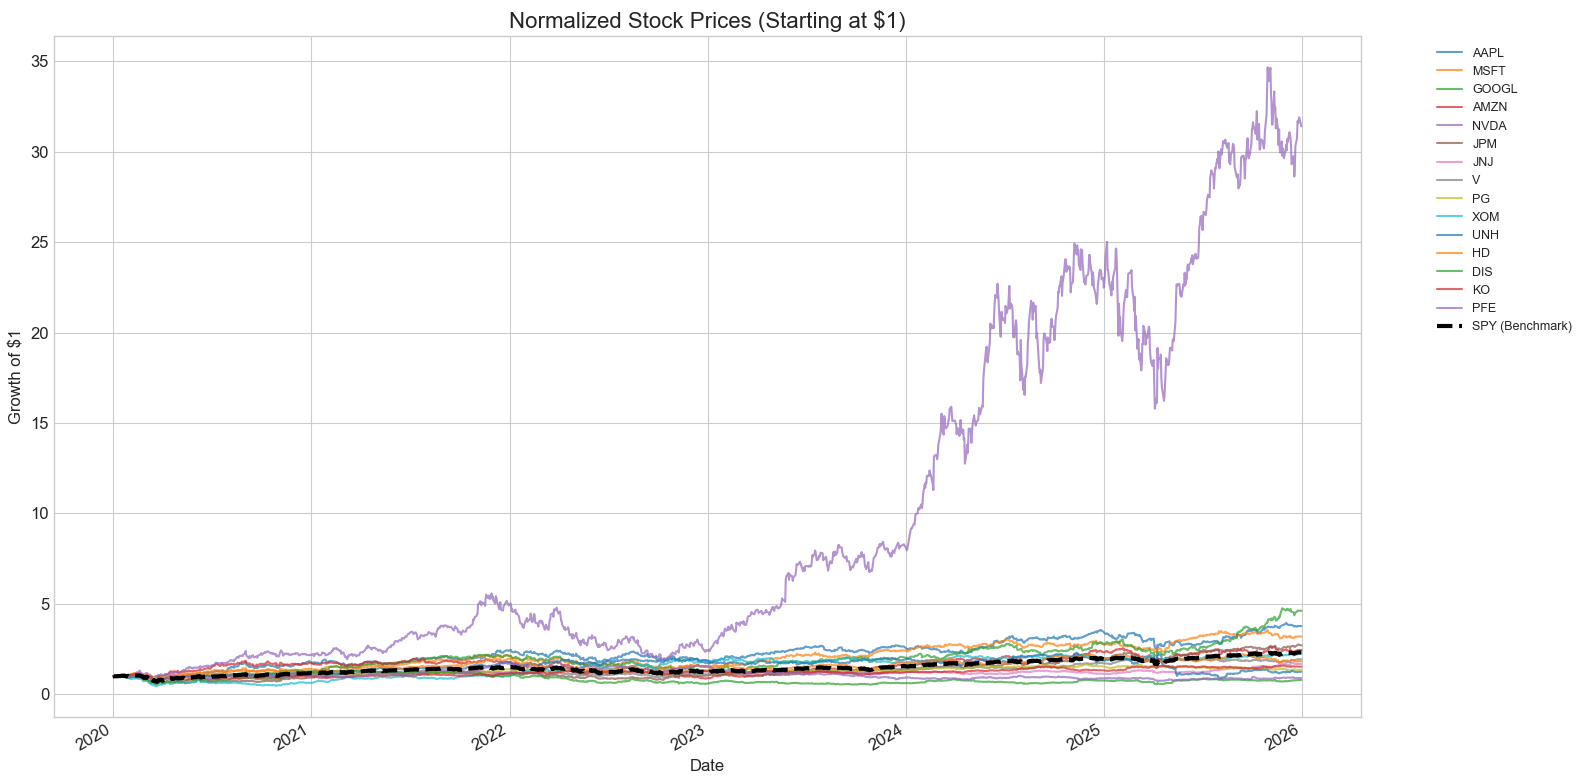


Interpretation: If a line is at 3.0, that means $1 invested grew to $3 (200% gain).
If a line is at 0.5, that means $1 invested shrunk to $0.50 (50% loss).


In [7]:
# Plot 1: Normalized Price Chart
# "Normalized" means we set every stock to start at $1 (or 100%)
# This lets us compare stocks fairly — a $3000 stock and a $50 stock
# can be shown on the same chart

normalized_prices = stock_prices / stock_prices.iloc[0]  # Divide by first day's price

fig, ax = plt.subplots(figsize=(16, 8))
normalized_prices.plot(ax=ax, alpha=0.7)  # alpha = transparency

# Also plot the benchmark
benchmark_norm = benchmark_prices / benchmark_prices.iloc[0]
benchmark_norm.plot(ax=ax, color='black', linewidth=3, linestyle='--', label='SPY (Benchmark)')

ax.set_title('Normalized Stock Prices (Starting at $1)', fontsize=16)
ax.set_ylabel('Growth of $1')
ax.set_xlabel('Date')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print('\nInterpretation: If a line is at 3.0, that means $1 invested grew to $3 (200% gain).')
print('If a line is at 0.5, that means $1 invested shrunk to $0.50 (50% loss).')

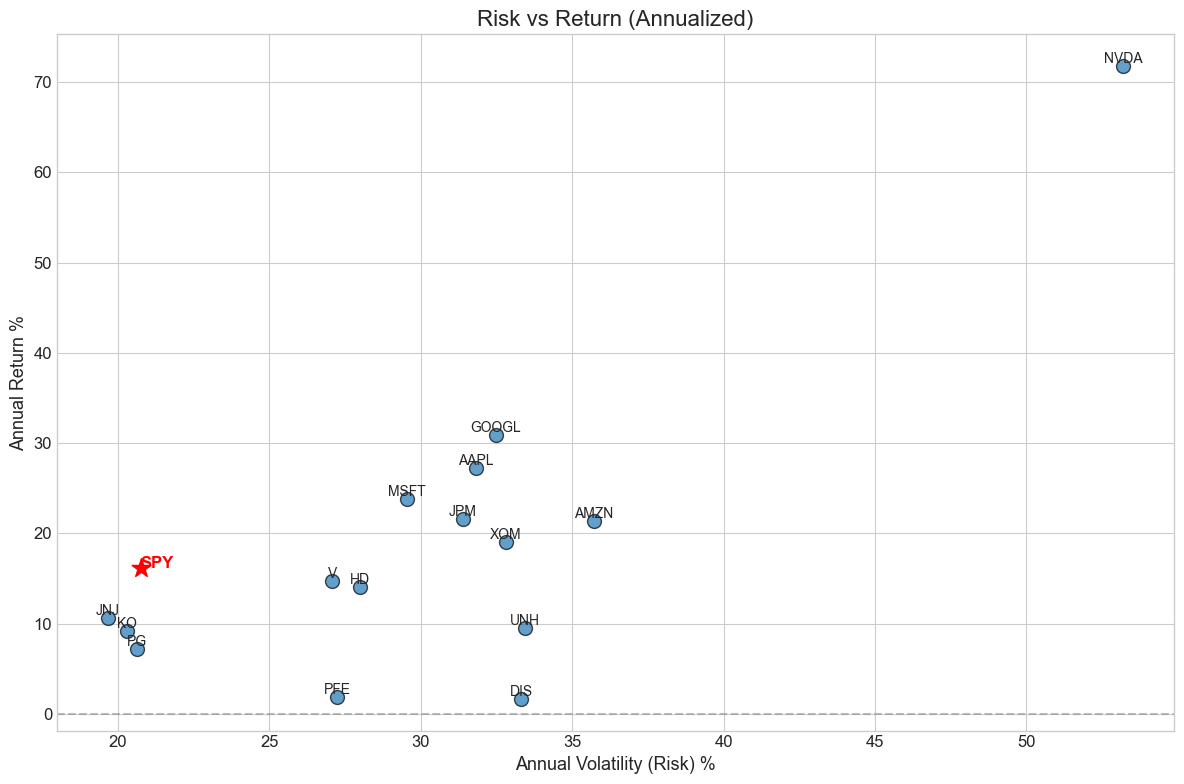

Stocks in the upper-left are the best: high return, low risk.
Stocks in the lower-right are the worst: low return, high risk.


In [8]:
# Plot 2: Risk vs Return Scatter Plot
# This is one of the most important charts in finance!
#
# X-axis: Risk (standard deviation of returns) — how much the price bounces around
# Y-axis: Return (average return) — how much money you make on average
#
# IDEAL: Top-left corner (high return, low risk)
# WORST: Bottom-right corner (low return, high risk)

annual_returns = stock_returns.mean() * 252  # 252 trading days per year
annual_volatility = stock_returns.std() * np.sqrt(252)  # Annualize the std dev

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(annual_volatility * 100, annual_returns * 100, s=100, alpha=0.7, edgecolors='black')

# Label each point with the stock ticker
for ticker in TICKERS:
    ax.annotate(ticker,
                (annual_volatility[ticker] * 100, annual_returns[ticker] * 100),
                fontsize=10, ha='center', va='bottom')

# Add benchmark point
bm_ret = benchmark_returns.mean() * 252 * 100
bm_vol = benchmark_returns.std() * np.sqrt(252) * 100
ax.scatter(bm_vol, bm_ret, s=200, color='red', marker='*', zorder=5, label='SPY')
ax.annotate('SPY', (bm_vol, bm_ret), fontsize=12, fontweight='bold', color='red')

ax.set_title('Risk vs Return (Annualized)', fontsize=16)
ax.set_xlabel('Annual Volatility (Risk) %', fontsize=13)
ax.set_ylabel('Annual Return %', fontsize=13)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('Stocks in the upper-left are the best: high return, low risk.')
print('Stocks in the lower-right are the worst: low return, high risk.')

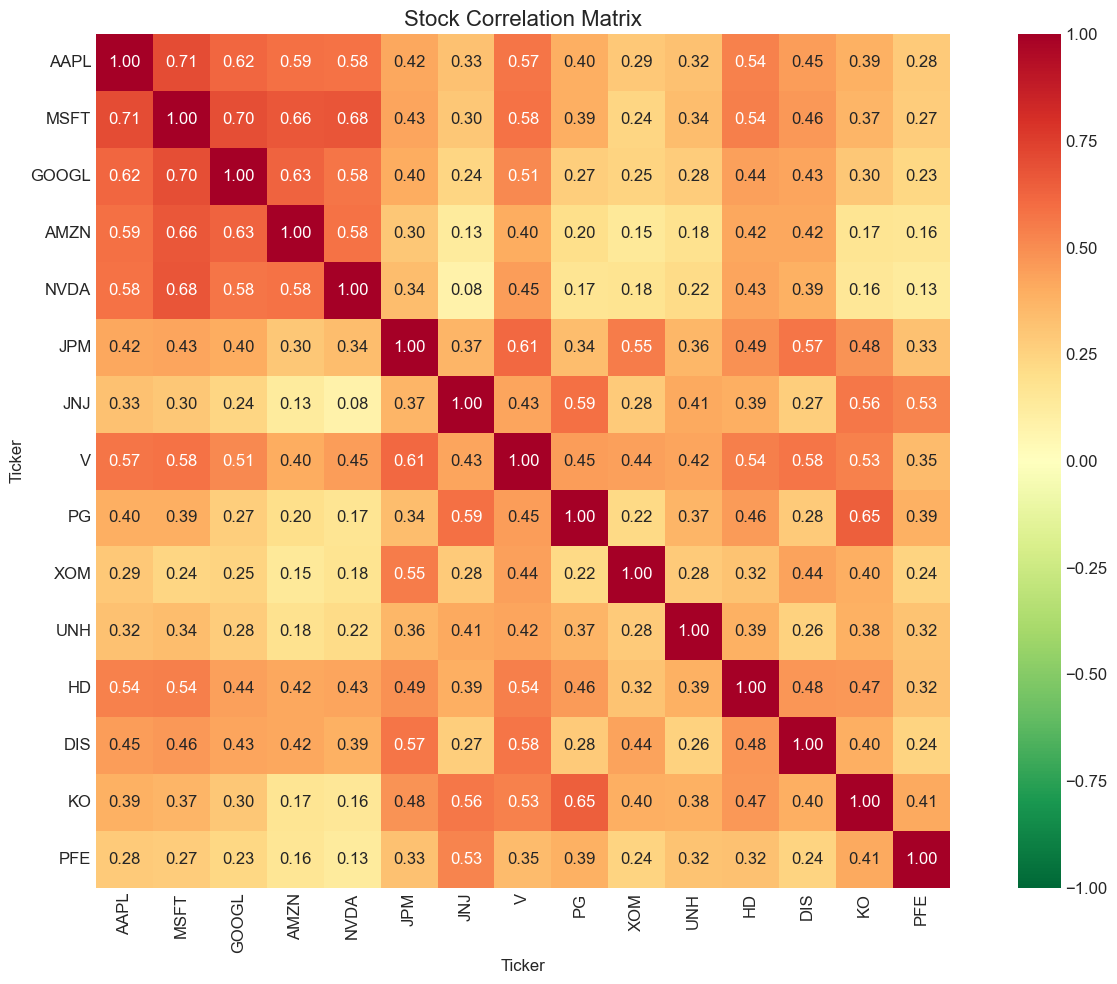


Red = high correlation (move together) — less diversification benefit
Green = low/negative correlation — great for diversification!


In [9]:
# Plot 3: Correlation Heatmap
# Correlation measures how much two stocks move TOGETHER
#
# Correlation = 1.0 → they move exactly the same (no diversification benefit)
# Correlation = 0.0 → completely independent (great for diversification!)
# Correlation = -1.0 → they move opposite (perfect hedge)
#
# For a good portfolio, we WANT low correlation between stocks

correlation_matrix = stock_returns.corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('Stock Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

print('\nRed = high correlation (move together) — less diversification benefit')
print('Green = low/negative correlation — great for diversification!')

In [10]:
# Summary Statistics Table
# Let's create a nice summary of each stock's characteristics

# Reuse the annualized values already computed in the scatter plot above
risk_free_rate = 0.04

summary = pd.DataFrame({
    'Annual Return (%)': (annual_returns * 100).round(2),
    'Annual Volatility (%)': (annual_volatility * 100).round(2),
    'Sharpe Ratio': ((annual_returns - risk_free_rate) / annual_volatility).round(3),
    'Max Drawdown (%)': ((stock_prices / stock_prices.cummax() - 1).min() * 100).round(2),
    'Total Return (%)': ((stock_prices.iloc[-1] / stock_prices.iloc[0] - 1) * 100).round(2)
})

# Sort by Sharpe Ratio (best risk-adjusted return first)
summary = summary.sort_values('Sharpe Ratio', ascending=False)

print('Stock Summary Statistics')
print('=' * 80)
print('\nSharpe Ratio = (Return - Risk-Free Rate) / Risk. Higher is better. Above 1.0 is considered good.')
print('Max Drawdown = Largest peak-to-trough decline. Less negative is better.\n')
summary

Stock Summary Statistics

Sharpe Ratio = (Return - Risk-Free Rate) / Risk. Higher is better. Above 1.0 is considered good.
Max Drawdown = Largest peak-to-trough decline. Less negative is better.



,Annual Return (%),Annual Volatility (%),Sharpe Ratio,Max Drawdown (%),Total Return (%)
Ticker,,,,,
NVDA,71.79,53.20,1.274,-66.34,3040.81
GOOGL,30.90,32.48,0.828,-44.32,362.08
AAPL,27.25,31.82,0.731,-33.36,276.83
MSFT,23.81,29.55,0.670,-37.15,219.65
JPM,21.57,31.39,0.560,-43.63,170.48
AMZN,21.37,35.71,0.486,-56.15,145.03
XOM,18.99,32.82,0.457,-55.00,125.47
V,14.66,27.07,0.394,-36.36,93.04
HD,14.02,28.00,0.358,-37.99,82.30


---
# Section 4: Technical Indicators

**Technical indicators** are mathematical calculations based on price and volume data. Traders use them as **signals** to decide when to buy or sell.

Think of them as **thermometers for the market** — they measure different aspects of price movement.

We'll calculate these indicators because both our RL agent and LLM agent will use them as inputs.

### Indicators We'll Use:

| Indicator | What It Measures | Buy Signal | Sell Signal |
|---|---|---|---|
| **SMA** (Simple Moving Average) | Average price over N days | Price crosses above SMA | Price crosses below SMA |
| **RSI** (Relative Strength Index) | Is the stock overbought or oversold? (0-100) | RSI < 30 (oversold) | RSI > 70 (overbought) |
| **MACD** | Momentum — is the trend strengthening? | MACD crosses above signal | MACD crosses below signal |
| **Bollinger Bands** | Is the price unusually high or low? | Price hits lower band | Price hits upper band |

In [11]:
import ta  # Technical Analysis library

def add_technical_indicators(df_price_series, ticker_name):
    """
    Given a Series of prices for one stock, calculate technical indicators.
    Returns a DataFrame with the original price + all indicators.
    """
    df = pd.DataFrame({'Close': df_price_series})
    
    # --- Moving Averages ---
    # SMA = average of the last N closing prices
    # If today's price is ABOVE the SMA, the stock is in an uptrend
    df['SMA_20'] = df['Close'].rolling(window=20).mean()   # 20-day (~1 month)
    df['SMA_50'] = df['Close'].rolling(window=50).mean()   # 50-day (~2.5 months)
    df['SMA_200'] = df['Close'].rolling(window=200).mean() # 200-day (~10 months)
    
    # --- RSI (Relative Strength Index) ---
    # Ranges from 0 to 100
    # < 30 = oversold (stock dropped too much, might bounce back → BUY signal)
    # > 70 = overbought (stock rose too much, might drop → SELL signal)
    df['RSI'] = ta.momentum.RSIIndicator(df['Close'], window=14).rsi()
    
    # --- MACD (Moving Average Convergence Divergence) ---
    # Measures momentum (speed of price change)
    # When MACD line crosses ABOVE signal line → bullish (BUY)
    # When MACD line crosses BELOW signal line → bearish (SELL)
    macd = ta.trend.MACD(df['Close'])
    df['MACD'] = macd.macd()
    df['MACD_Signal'] = macd.macd_signal()
    df['MACD_Hist'] = macd.macd_diff()  # Histogram = MACD - Signal
    
    # --- Bollinger Bands ---
    # Creates a "band" around the price
    # Upper band = SMA + 2*std_dev (price is unusually HIGH)
    # Lower band = SMA - 2*std_dev (price is unusually LOW)
    # Price touching lower band → might bounce up (BUY)
    # Price touching upper band → might drop (SELL)
    bb = ta.volatility.BollingerBands(df['Close'])
    df['BB_Upper'] = bb.bollinger_hband()
    df['BB_Lower'] = bb.bollinger_lband()
    df['BB_Mid'] = bb.bollinger_mavg()
    
    # --- Volatility (ATR - Average True Range) ---
    # Measures how much the price moves on average
    # High ATR = volatile stock, Low ATR = stable stock
    df['Daily_Return'] = df['Close'].pct_change()
    df['Volatility_20'] = df['Daily_Return'].rolling(window=20).std() * np.sqrt(252)
    
    return df

# Calculate indicators for all stocks
indicators_dict = {}
for ticker in TICKERS:
    indicators_dict[ticker] = add_technical_indicators(stock_prices[ticker], ticker)

print(f'Calculated technical indicators for {len(indicators_dict)} stocks.')
print(f'\nIndicators for AAPL (last 5 rows):')
indicators_dict['AAPL'].tail()

Calculated technical indicators for 15 stocks.

Indicators for AAPL (last 5 rows):


,Close,SMA_20,SMA_50,SMA_200,RSI,MACD,MACD_Signal,MACD_Hist,BB_Upper,BB_Lower,BB_Mid,Daily_Return,Volatility_20
Date,,,,,,,,,,,,,
2025-12-23,272.105377,277.050758,270.176155,229.717952,47.028995,0.370372,1.729160,-1.358788,285.178861,268.922656,277.050758,0.005130,0.124685
2025-12-24,273.554016,276.892905,270.701263,229.986314,50.012072,0.302467,1.443821,-1.141354,285.162654,268.623156,276.892905,0.005324,0.125514
2025-12-26,273.144409,276.685599,271.186837,230.271844,49.168915,0.213143,1.197686,-0.984543,285.111480,268.259718,276.685599,-0.001497,0.125160
2025-12-29,273.504089,276.431337,271.717334,230.595514,49.966593,0.169423,0.992033,-0.822610,284.918765,267.943909,276.431337,0.001317,0.123793
2025-12-30,272.824707,275.930804,272.137628,230.896820,48.420933,0.079044,0.809435,-0.730392,284.019906,267.841703,275.930804,-0.002484,0.108157


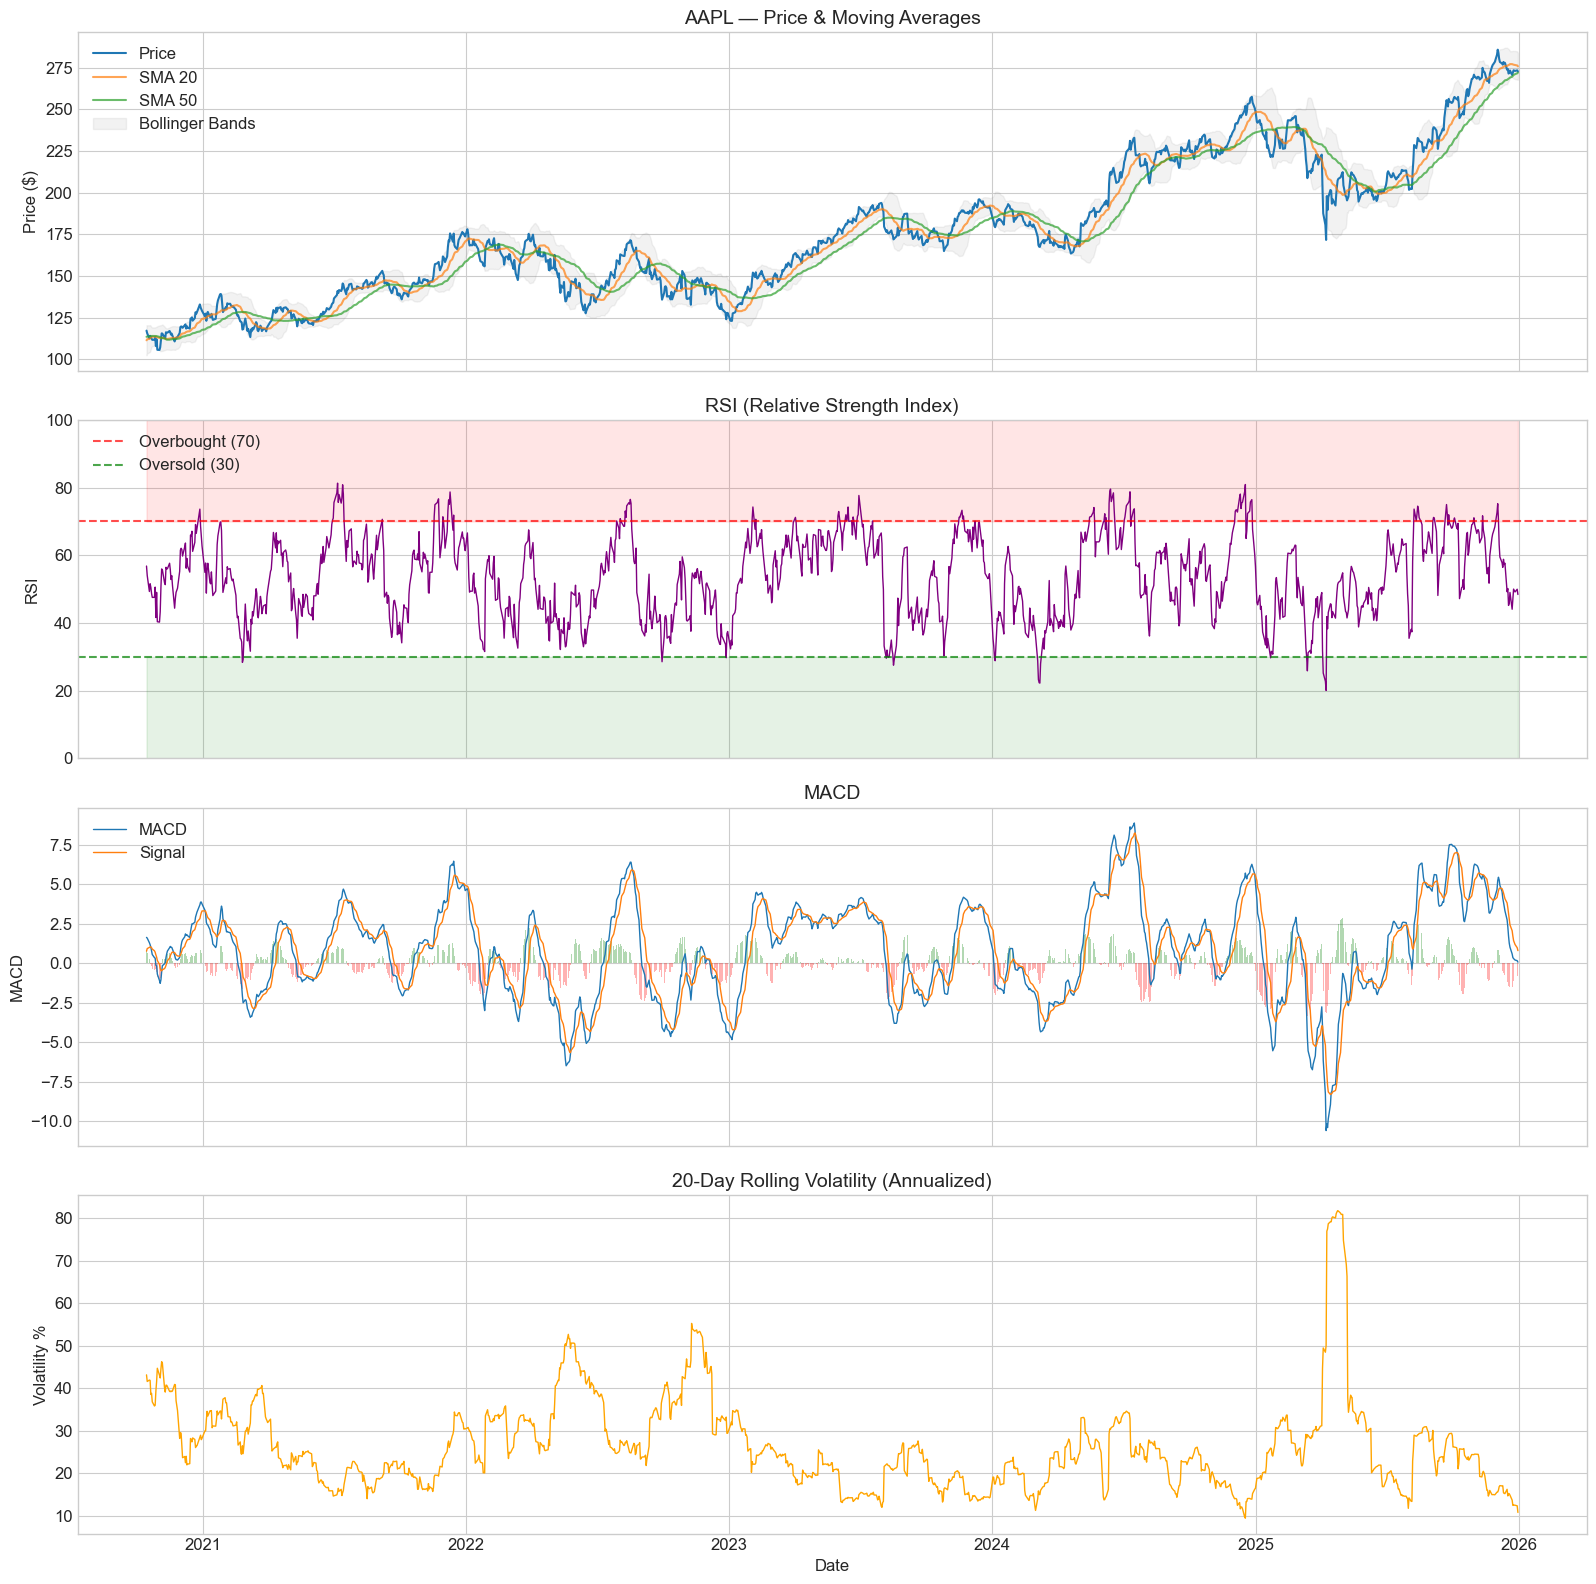

In [12]:
# Visualize indicators for one stock (AAPL as example)
# This helps us understand what the indicators look like

example_stock = 'AAPL'
df_ex = indicators_dict[example_stock].dropna()

fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)

# Panel 1: Price + Moving Averages + Bollinger Bands
axes[0].plot(df_ex.index, df_ex['Close'], label='Price', linewidth=1.5)
axes[0].plot(df_ex.index, df_ex['SMA_20'], label='SMA 20', alpha=0.7)
axes[0].plot(df_ex.index, df_ex['SMA_50'], label='SMA 50', alpha=0.7)
axes[0].fill_between(df_ex.index, df_ex['BB_Upper'], df_ex['BB_Lower'], alpha=0.1, color='gray', label='Bollinger Bands')
axes[0].set_title(f'{example_stock} — Price & Moving Averages', fontsize=14)
axes[0].legend(loc='upper left')
axes[0].set_ylabel('Price ($)')

# Panel 2: RSI
axes[1].plot(df_ex.index, df_ex['RSI'], color='purple', linewidth=1)
axes[1].axhline(y=70, color='red', linestyle='--', alpha=0.7, label='Overbought (70)')
axes[1].axhline(y=30, color='green', linestyle='--', alpha=0.7, label='Oversold (30)')
axes[1].fill_between(df_ex.index, 70, 100, alpha=0.1, color='red')
axes[1].fill_between(df_ex.index, 0, 30, alpha=0.1, color='green')
axes[1].set_title('RSI (Relative Strength Index)', fontsize=14)
axes[1].set_ylabel('RSI')
axes[1].set_ylim(0, 100)
axes[1].legend(loc='upper left')

# Panel 3: MACD
axes[2].plot(df_ex.index, df_ex['MACD'], label='MACD', linewidth=1)
axes[2].plot(df_ex.index, df_ex['MACD_Signal'], label='Signal', linewidth=1)
colors = ['green' if v >= 0 else 'red' for v in df_ex['MACD_Hist']]
axes[2].bar(df_ex.index, df_ex['MACD_Hist'], color=colors, alpha=0.3, width=1)
axes[2].set_title('MACD', fontsize=14)
axes[2].set_ylabel('MACD')
axes[2].legend(loc='upper left')

# Panel 4: Volatility
axes[3].plot(df_ex.index, df_ex['Volatility_20'] * 100, color='orange', linewidth=1)
axes[3].set_title('20-Day Rolling Volatility (Annualized)', fontsize=14)
axes[3].set_ylabel('Volatility %')
axes[3].set_xlabel('Date')

plt.tight_layout()
plt.show()

---
# Section 5: Benchmark Strategy 1 — Buy and Hold S&P 500

This is the **simplest possible strategy**: buy the S&P 500 index on day 1 and hold forever.

**Why is this our benchmark?** Because if our fancy algorithm can't beat someone who just buys SPY and does nothing, then our algorithm is useless!

This is the bar we need to clear.

In [13]:
# Buy-and-Hold S&P 500 Strategy
# Simply invest all money in SPY on the first day

# Calculate cumulative returns
# If daily returns are +1%, +2%, -0.5%, the cumulative return is:
# (1 + 0.01) * (1 + 0.02) * (1 - 0.005) - 1 = compounded growth

benchmark_cumulative = (1 + benchmark_returns).cumprod()  # cumprod = cumulative product
benchmark_portfolio_value = INITIAL_CAPITAL * benchmark_cumulative

# Calculate key performance metrics
def calculate_performance_metrics(returns, name='Strategy'):
    """
    Calculate standard trading performance metrics.
    
    Parameters:
    - returns: pd.Series of daily returns (e.g., 0.02 means +2%)
    - name: label for the strategy
    
    Returns: dictionary of metrics
    """
    total_return = (1 + returns).prod() - 1  # Total compounded return
    n_years = len(returns) / 252
    annual_return = (1 + total_return) ** (1 / n_years) - 1  # Annualized
    annual_vol = returns.std() * np.sqrt(252)
    
    # Sharpe Ratio: (return - risk_free_rate) / volatility
    # We assume risk-free rate = 4% (approximate US Treasury rate)
    risk_free_rate = 0.04
    sharpe = (annual_return - risk_free_rate) / annual_vol
    
    # Max Drawdown: largest peak-to-trough decline
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()  # Running maximum
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()
    
    # Sortino Ratio: like Sharpe but only penalizes downside volatility
    # (we don't mind upside volatility!)
    downside_returns = returns[returns < 0]
    downside_vol = downside_returns.std() * np.sqrt(252)
    sortino = (annual_return - risk_free_rate) / downside_vol if downside_vol > 0 else 0
    
    # Calmar Ratio: annual return / max drawdown
    calmar = annual_return / abs(max_drawdown) if max_drawdown != 0 else 0
    
    # Win rate: percentage of days with positive returns
    win_rate = (returns > 0).mean()
    
    return {
        'Strategy': name,
        'Total Return (%)': round(total_return * 100, 2),
        'Annual Return (%)': round(annual_return * 100, 2),
        'Annual Volatility (%)': round(annual_vol * 100, 2),
        'Sharpe Ratio': round(sharpe, 3),
        'Sortino Ratio': round(sortino, 3),
        'Calmar Ratio': round(calmar, 3),
        'Max Drawdown (%)': round(max_drawdown * 100, 2),
        'Win Rate (%)': round(win_rate * 100, 2),
    }

# Calculate metrics for buy-and-hold
bh_metrics = calculate_performance_metrics(benchmark_returns, 'Buy & Hold SPY')

print('Benchmark: Buy & Hold S&P 500 (SPY)')
print('=' * 50)
for key, value in bh_metrics.items():
    if key != 'Strategy':
        print(f'{key}: {value}')

Benchmark: Buy & Hold S&P 500 (SPY)
Total Return (%): 130.77
Annual Return (%): 15.02
Annual Volatility (%): 20.75
Sharpe Ratio: 0.531
Sortino Ratio: 0.652
Calmar Ratio: 0.445
Max Drawdown (%): -33.72
Win Rate (%): 55.18


---
# Section 6: Benchmark Strategy 2 — Mean-Variance Optimization (MVO)

## The Big Idea (Markowitz Portfolio Theory)

Imagine you have $100 and 15 stocks to choose from. How do you split the money?

**Mean-Variance Optimization** answers this mathematically:
- **Mean** = expected return (how much money you'll make)
- **Variance** = risk (how much the value bounces around)

The goal is to find the **optimal mix of stocks** that gives you the **highest return for a given level of risk** (or lowest risk for a given return).

### Intuition
- Putting all money in one stock = risky (if it crashes, you lose everything)
- Spreading money across many stocks = safer (some go up while others go down)
- BUT not all combinations are equal — MVO finds the BEST combination

### The Efficient Frontier
When you plot all possible portfolio combinations on a Risk vs Return chart, the best ones form a curve called the **Efficient Frontier** — you cannot do better than this curve.

We'll find the portfolio on this frontier with the **Maximum Sharpe Ratio** (best risk-adjusted return).

In [14]:
# ===================================================================
# MEAN-VARIANCE OPTIMIZATION
# ===================================================================

# Split data into TRAINING and TESTING periods
# Training: we use this data to FIND the optimal portfolio weights
# Testing: we use this to see if the weights actually work on NEW data
#
# This is like studying for an exam (training) vs taking the exam (testing)
# If you only test on what you studied, you don't know if you truly learned!

SPLIT_DATE = '2024-07-01'  # Single boundary — train on everything before, test on everything after

train_returns = stock_returns[stock_returns.index < SPLIT_DATE]
test_returns = stock_returns[stock_returns.index >= SPLIT_DATE]

print(f'Training period: {train_returns.index[0].date()} to {train_returns.index[-1].date()} ({len(train_returns)} days)')
print(f'Testing period:  {test_returns.index[0].date()} to {test_returns.index[-1].date()} ({len(test_returns)} days)')

Training period: 2020-01-03 to 2024-06-28 (1129 days)
Testing period:  2024-07-01 to 2025-12-30 (377 days)


In [15]:
# Step 1: Calculate the inputs for MVO
# We need:
#   - Expected returns for each stock (we use historical average as estimate)
#   - Covariance matrix (measures how stocks move together)

# Expected annual returns (from training data only!)
expected_returns = train_returns.mean() * 252

# Covariance matrix (annualized)
# Covariance tells us: when Stock A goes up, does Stock B go up too?
cov_matrix = train_returns.cov() * 252

n_assets = len(TICKERS)

print('Expected Annual Returns (from training data):')
print((expected_returns * 100).round(2).to_string())
print(f'\nCovariance matrix shape: {cov_matrix.shape}')

Expected Annual Returns (from training data):
Ticker
AAPL     29.01
MSFT     28.69
GOOGL    27.33
AMZN     22.53
NVDA     82.17
JPM      16.46
JNJ       4.79
V        11.88
PG       11.23
XOM      22.22
UNH      18.34
HD       16.93
DIS      -2.75
KO        8.72
PFE       1.70

Covariance matrix shape: (15, 15)


In [16]:
# Step 2: Define the optimization functions

def portfolio_return(weights, expected_returns):
    """
    Calculate portfolio expected return.
    It's simply the weighted average of individual stock returns.
    
    Example: If you put 50% in Stock A (10% return) and 50% in Stock B (20% return),
    portfolio return = 0.5 * 10% + 0.5 * 20% = 15%
    """
    return np.dot(weights, expected_returns)  # dot product = weighted sum

def portfolio_volatility(weights, cov_matrix):
    """
    Calculate portfolio risk (standard deviation).
    This is NOT just the weighted average of individual risks!
    Correlations between stocks matter — this is why diversification works.
    """
    return np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

def negative_sharpe_ratio(weights, expected_returns, cov_matrix, risk_free_rate=0.04):
    """
    We want to MAXIMIZE Sharpe Ratio, but scipy.optimize.minimize MINIMIZES.
    So we minimize the NEGATIVE Sharpe Ratio (minimizing a negative = maximizing the positive).
    """
    p_ret = portfolio_return(weights, expected_returns)
    p_vol = portfolio_volatility(weights, cov_matrix)
    return -(p_ret - risk_free_rate) / p_vol

def minimize_volatility(weights, cov_matrix):
    """Find the portfolio with the absolute lowest risk."""
    return portfolio_volatility(weights, cov_matrix)

print('Optimization functions defined.')

Optimization functions defined.


In [17]:
# Step 3: Find the Optimal Portfolios

# Constraints:
# 1. All weights must sum to 1 (we invest all our money)
# 2. Each weight must be between 0 and 1 (no short selling)

constraints = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1})  # weights sum to 1
bounds = tuple((0, 1) for _ in range(n_assets))  # 0 <= weight <= 1 for each stock
initial_weights = np.array([1/n_assets] * n_assets)  # Start with equal weights

# --- Optimal Portfolio 1: Maximum Sharpe Ratio ---
# This is the portfolio with the best risk-adjusted return
result_sharpe = minimize(
    negative_sharpe_ratio,
    initial_weights,
    args=(expected_returns, cov_matrix),
    method='SLSQP',  # Optimization algorithm
    bounds=bounds,
    constraints=constraints
)
optimal_weights_sharpe = result_sharpe.x

# --- Optimal Portfolio 2: Minimum Volatility ---
# This is the safest possible portfolio
result_minvol = minimize(
    minimize_volatility,
    initial_weights,
    args=(cov_matrix,),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)
optimal_weights_minvol = result_minvol.x

# --- Equal Weight Portfolio (simple benchmark) ---
equal_weights = np.array([1/n_assets] * n_assets)

# Display the Max Sharpe portfolio weights
print('MAXIMUM SHARPE RATIO PORTFOLIO')
print('=' * 50)
weights_df = pd.DataFrame({
    'Ticker': TICKERS,
    'Max Sharpe Weight (%)': (optimal_weights_sharpe * 100).round(2),
    'Min Vol Weight (%)': (optimal_weights_minvol * 100).round(2),
    'Equal Weight (%)': (equal_weights * 100).round(2)
}).set_index('Ticker')

# Only show stocks with > 0.1% allocation
print(weights_df[weights_df['Max Sharpe Weight (%)'] > 0.1].to_string())

print(f'\nMax Sharpe — Expected Return: {portfolio_return(optimal_weights_sharpe, expected_returns)*100:.2f}%, '
      f'Volatility: {portfolio_volatility(optimal_weights_sharpe, cov_matrix)*100:.2f}%')
print(f'Min Vol    — Expected Return: {portfolio_return(optimal_weights_minvol, expected_returns)*100:.2f}%, '
      f'Volatility: {portfolio_volatility(optimal_weights_minvol, cov_matrix)*100:.2f}%')

MAXIMUM SHARPE RATIO PORTFOLIO
        Max Sharpe Weight (%)  Min Vol Weight (%)  Equal Weight (%)
Ticker                                                             
NVDA                     79.1                0.00              6.67
XOM                      20.9                6.64              6.67

Max Sharpe — Expected Return: 69.64%, Volatility: 44.80%
Min Vol    — Expected Return: 9.72%, Volatility: 17.40%


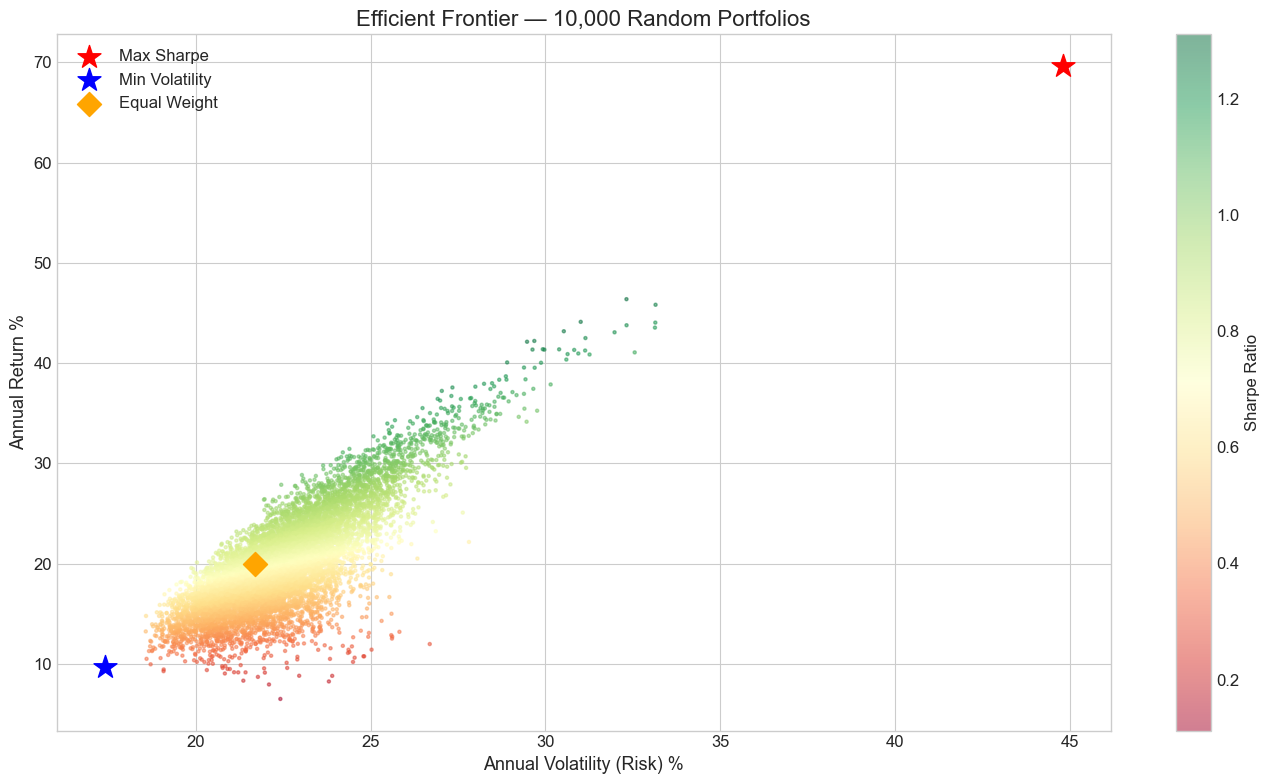

The efficient frontier is the upper-left edge of the cloud.
No portfolio can exist above this edge — it represents the best possible trade-off.


In [18]:
# Step 4: Plot the Efficient Frontier
# Generate many random portfolios to show all possible combinations

n_portfolios = 10000  # Generate 10,000 random portfolio combinations

# Vectorized approach: generate all random weights at once (much faster than a loop)
np.random.seed(42)  # For reproducibility
W = np.random.dirichlet(np.ones(n_assets), size=n_portfolios)  # Shape: (10000, 15)

# Portfolio returns: weighted sum of expected returns for each portfolio
port_returns = W @ expected_returns.values * 100  # Shape: (10000,)

# Portfolio volatilities: sqrt of quadratic form w' * Cov * w
# np.einsum computes this for all portfolios at once without a loop
port_vols = np.sqrt(np.einsum('ij,jk,ik->i', W, cov_matrix.values, W)) * 100

# Sharpe ratios
port_sharpes = (port_returns - 4) / port_vols  # 4% risk-free rate

results = np.array([port_returns, port_vols, port_sharpes])

fig, ax = plt.subplots(figsize=(14, 8))

# Plot random portfolios, colored by Sharpe ratio
scatter = ax.scatter(results[1], results[0], c=results[2], cmap='RdYlGn',
                     marker='o', s=5, alpha=0.5)
plt.colorbar(scatter, label='Sharpe Ratio')

# Plot optimal portfolios
opt_ret = portfolio_return(optimal_weights_sharpe, expected_returns) * 100
opt_vol = portfolio_volatility(optimal_weights_sharpe, cov_matrix) * 100
ax.scatter(opt_vol, opt_ret, color='red', marker='*', s=300, zorder=5, label='Max Sharpe')

mv_ret = portfolio_return(optimal_weights_minvol, expected_returns) * 100
mv_vol = portfolio_volatility(optimal_weights_minvol, cov_matrix) * 100
ax.scatter(mv_vol, mv_ret, color='blue', marker='*', s=300, zorder=5, label='Min Volatility')

eq_ret = portfolio_return(equal_weights, expected_returns) * 100
eq_vol = portfolio_volatility(equal_weights, cov_matrix) * 100
ax.scatter(eq_vol, eq_ret, color='orange', marker='D', s=150, zorder=5, label='Equal Weight')

ax.set_title('Efficient Frontier — 10,000 Random Portfolios', fontsize=16)
ax.set_xlabel('Annual Volatility (Risk) %', fontsize=13)
ax.set_ylabel('Annual Return %', fontsize=13)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print('The efficient frontier is the upper-left edge of the cloud.')
print('No portfolio can exist above this edge — it represents the best possible trade-off.')

In [19]:
# Step 5: Backtest the MVO strategy on TEST data
# We use the weights found from training data and apply them to the test period

# Calculate daily portfolio returns for the test period
mvo_test_returns = test_returns @ optimal_weights_sharpe  # @ = matrix multiplication
minvol_test_returns = test_returns @ optimal_weights_minvol
equal_test_returns = test_returns @ equal_weights

# Get benchmark returns for the same test period
benchmark_test_returns = benchmark_returns[benchmark_returns.index >= SPLIT_DATE]
# Align dates
common_idx = mvo_test_returns.index.intersection(benchmark_test_returns.index)
mvo_test_returns = mvo_test_returns.loc[common_idx]
minvol_test_returns = minvol_test_returns.loc[common_idx]
equal_test_returns = equal_test_returns.loc[common_idx]
benchmark_test_returns = benchmark_test_returns.loc[common_idx]

# Calculate metrics
mvo_metrics = calculate_performance_metrics(mvo_test_returns, 'MVO (Max Sharpe)')
minvol_metrics = calculate_performance_metrics(minvol_test_returns, 'MVO (Min Vol)')
equal_metrics = calculate_performance_metrics(equal_test_returns, 'Equal Weight')
bh_test_metrics = calculate_performance_metrics(benchmark_test_returns, 'Buy & Hold SPY')

# Display comparison table
comparison_df = pd.DataFrame([mvo_metrics, minvol_metrics, equal_metrics, bh_test_metrics]).set_index('Strategy')
print('BENCHMARK STRATEGIES — TEST PERIOD PERFORMANCE')
print('=' * 80)
comparison_df

BENCHMARK STRATEGIES — TEST PERIOD PERFORMANCE


,Total Return (%),Annual Return (%),Annual Volatility (%),Sharpe Ratio,Sortino Ratio,Calmar Ratio,Max Drawdown (%),Win Rate (%)
Strategy,,,,,,,,
MVO (Max Sharpe),47.16,29.47,40.83,0.624,0.856,0.940,-31.36,54.11
MVO (Min Vol),21.18,13.70,12.34,0.786,1.141,1.382,-9.92,53.58
Equal Weight,25.10,16.15,14.21,0.855,1.138,1.063,-15.19,56.50
Buy & Hold SPY,28.54,18.27,17.86,0.799,1.006,0.974,-18.76,58.36


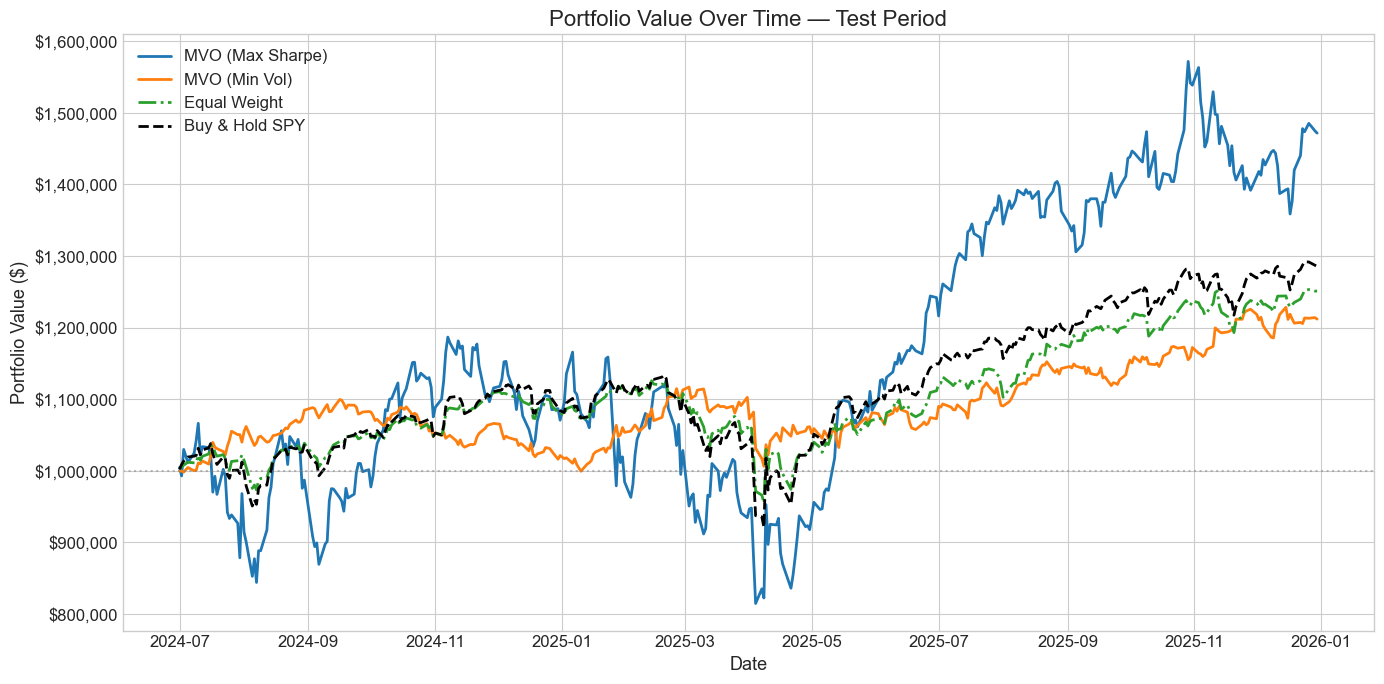

In [20]:
# Plot cumulative returns comparison for the test period

fig, ax = plt.subplots(figsize=(14, 7))

cum_mvo = (1 + mvo_test_returns).cumprod() * INITIAL_CAPITAL
cum_minvol = (1 + minvol_test_returns).cumprod() * INITIAL_CAPITAL
cum_equal = (1 + equal_test_returns).cumprod() * INITIAL_CAPITAL
cum_bh = (1 + benchmark_test_returns).cumprod() * INITIAL_CAPITAL

ax.plot(cum_mvo.index, cum_mvo, label='MVO (Max Sharpe)', linewidth=2)
ax.plot(cum_minvol.index, cum_minvol, label='MVO (Min Vol)', linewidth=2)
ax.plot(cum_equal.index, cum_equal, label='Equal Weight', linewidth=2, linestyle='-.')
ax.plot(cum_bh.index, cum_bh, label='Buy & Hold SPY', linewidth=2, linestyle='--', color='black')

ax.axhline(y=INITIAL_CAPITAL, color='gray', linestyle=':', alpha=0.5)
ax.set_title('Portfolio Value Over Time — Test Period', fontsize=16)
ax.set_ylabel('Portfolio Value ($)', fontsize=13)
ax.set_xlabel('Date', fontsize=13)
ax.legend(fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

---
# Section 7: PATH A — Reinforcement Learning with FinRL

## What is Reinforcement Learning?

Imagine teaching a dog to do tricks:
1. The dog tries something (an **action**)
2. If it works, you give a treat (**positive reward**)
3. If it doesn't, no treat (**negative reward**)
4. Over time, the dog learns which actions get treats

Reinforcement Learning (RL) works the same way, but with a **computer agent** instead of a dog:

```
Agent (the trader bot) observes the Market (state)
    → Decides to BUY / SELL / HOLD (action)
    → Market moves, portfolio value changes (reward)
    → Agent learns from the outcome
    → Repeat thousands of times
```

## What is FinRL?

FinRL is a Python library that sets up the entire RL trading framework for you:
- It creates the **environment** (simulated stock market)
- It provides the **agent** (the RL algorithm that learns)
- It handles **state** (what the agent sees: prices, indicators, portfolio)
- It defines the **reward** (portfolio return)

### RL Algorithms We Use:
| Algorithm | Full Name | Behavior |
|---|---|---|
| **PPO** | Proximal Policy Optimization | Balanced, stable, most popular |
| **A2C** | Advantage Actor-Critic | Fast training, good for simple environments |
| **DDPG** | Deep Deterministic Policy Gradient | Good for continuous action spaces (how much to buy/sell) |

In [21]:
# ===================================================================
# PATH A: REINFORCEMENT LEARNING WITH FinRL
# ===================================================================

# Step 1: Prepare data in FinRL's required format
# FinRL expects a specific DataFrame format with columns:
# date, tic (ticker), open, high, low, close, volume + technical indicators

from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import FeatureEngineer
from finrl.meta.env_stock_trading.env_stocktrading import StockTradingEnv
from finrl.agents.stablebaselines3.models import DRLAgent
from stable_baselines3 import PPO, A2C, DDPG

print('FinRL modules loaded successfully!')
print('\nNow downloading data in FinRL format...')

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


FinRL modules loaded successfully!

Now downloading data in FinRL format...


In [22]:
# Download data directly (FinRL's YahooDownloader is incompatible with newer yfinance)
# We format it in the same structure FinRL expects: date, open, high, low, close, volume, tic

import yfinance as yf

data_frames = []
for tic in TICKERS:
    temp_df = yf.download(tic, start=START_DATE, end=END_DATE, auto_adjust=True, progress=False)
    temp_df.columns = temp_df.columns.droplevel('Ticker') if isinstance(temp_df.columns, pd.MultiIndex) else temp_df.columns
    temp_df = temp_df.reset_index()
    temp_df.columns = [c.lower() for c in temp_df.columns]
    temp_df['tic'] = tic
    data_frames.append(temp_df)

df_finrl = pd.concat(data_frames, ignore_index=True)
df_finrl = df_finrl.sort_values(['date', 'tic']).reset_index(drop=True)
df_finrl['day'] = df_finrl['date'].dt.dayofweek

print(f'Downloaded {len(df_finrl)} rows')
print(f'Columns: {list(df_finrl.columns)}')
df_finrl.head()

Downloaded 22605 rows
Columns: ['date', 'close', 'high', 'low', 'open', 'volume', 'tic', 'day']


,date,close,high,low,open,volume,tic,day
0,2020-01-02,72.400528,72.460791,71.156689,71.409793,135480400,AAPL,3
1,2020-01-02,94.900497,94.900497,93.207497,93.750000,80580000,AMZN,3
2,2020-01-02,144.790253,144.790253,141.761586,141.947202,9502100,DIS,3
3,2020-01-02,67.873032,67.873032,66.772629,66.867843,27278000,GOOGL,3
4,2020-01-02,188.727631,188.813541,187.163915,188.229304,3935700,HD,3


In [23]:
# Step 2: Add technical indicators using FinRL's FeatureEngineer
# This automatically calculates MACD, RSI, and other indicators

INDICATORS = ['macd', 'rsi_30', 'cci_30', 'dx_30']  # Common indicators
# macd = momentum
# rsi = overbought/oversold
# cci = Commodity Channel Index (another momentum indicator)
# dx = directional movement (trend strength)

fe = FeatureEngineer(
    use_technical_indicator=True,
    tech_indicator_list=INDICATORS,
    use_turbulence=True,  # Turbulence index: measures market stress
    user_defined_feature=False
)

df_processed = fe.preprocess_data(df_finrl)
df_processed = df_processed.sort_values(['date', 'tic']).reset_index(drop=True)

print(f'Processed data shape: {df_processed.shape}')
print(f'Columns: {list(df_processed.columns)}')
df_processed.head(10)

Successfully added technical indicators
Successfully added turbulence index
Processed data shape: (22605, 13)
Columns: ['date', 'close', 'high', 'low', 'open', 'volume', 'tic', 'day', 'macd', 'rsi_30', 'cci_30', 'dx_30', 'turbulence']


,date,close,high,low,open,volume,tic,day,macd,rsi_30,cci_30,dx_30,turbulence
0,2020-01-02,72.400528,72.460791,71.156689,71.409793,135480400,AAPL,3,0.0,50.0,0.0,0.0,0.0
1,2020-01-02,94.900497,94.900497,93.207497,93.750000,80580000,AMZN,3,0.0,50.0,0.0,0.0,0.0
2,2020-01-02,144.790253,144.790253,141.761586,141.947202,9502100,DIS,3,0.0,50.0,0.0,0.0,0.0
3,2020-01-02,67.873032,67.873032,66.772629,66.867843,27278000,GOOGL,3,0.0,50.0,0.0,0.0,0.0
4,2020-01-02,188.727631,188.813541,187.163915,188.229304,3935700,HD,3,0.0,50.0,0.0,0.0,0.0
5,2020-01-02,122.638237,122.680248,121.890495,122.554216,5777000,JNJ,3,0.0,50.0,0.0,0.0,0.0
6,2020-01-02,119.036400,119.044845,117.492443,117.939599,10803700,JPM,3,0.0,50.0,0.0,0.0,0.0
7,2020-01-02,45.432709,45.796235,45.242680,45.705353,11867700,KO,3,0.0,50.0,0.0,0.0,0.0
8,2020-01-02,152.158371,152.262577,149.989017,150.415308,22622100,MSFT,3,0.0,50.0,0.0,0.0,0.0
9,2020-01-02,5.970755,5.970755,5.891364,5.941886,237536000,NVDA,3,0.0,50.0,0.0,0.0,0.0


In [24]:
# Step 3: Split into train and test (trade) datasets

train_df = df_processed[df_processed['date'] < SPLIT_DATE].reset_index(drop=True)
test_df = df_processed[df_processed['date'] >= SPLIT_DATE].reset_index(drop=True)

# FinRL requires a sorted index where each integer index maps to all tickers for that date
# Verify the data has the right shape
n_tickers = len(train_df['tic'].unique())
train_df.index = train_df.index // n_tickers
test_df.index = test_df.index // n_tickers

print(f'Training data: {len(train_df)} rows ({train_df["date"].min()} to {train_df["date"].max()})')
print(f'Testing data:  {len(test_df)} rows ({test_df["date"].min()} to {test_df["date"].max()})')
print(f'Tickers per day: {n_tickers}')

Training data: 16950 rows (2020-01-02 00:00:00 to 2024-06-28 00:00:00)
Testing data:  5655 rows (2024-07-01 00:00:00 to 2025-12-30 00:00:00)
Tickers per day: 15


In [25]:
# Step 4: Set up the RL environment
# The "environment" is the simulated stock market the agent trades in

# Environment parameters
stock_dimension = len(TICKERS)
state_space = 1 + 2 * stock_dimension + len(INDICATORS) * stock_dimension
# State includes: [cash balance, stock prices, shares held, technical indicators]

# How much can the agent buy/sell at once?
# hmax = maximum number of shares per trade
hmax = 100

# Transaction cost = 0.1% per trade (realistic brokerage fee)
buy_cost = sell_cost = [0.001] * stock_dimension

env_kwargs = {
    'hmax': hmax,
    'initial_amount': INITIAL_CAPITAL,
    'buy_cost_pct': buy_cost,
    'sell_cost_pct': sell_cost,
    'state_space': state_space,
    'num_stock_shares': [0] * stock_dimension,
    'stock_dim': stock_dimension,
    'tech_indicator_list': INDICATORS,
    'action_space': stock_dimension,  # One action per stock
    'reward_scaling': 1e-4  # Scale rewards so the agent learns stably
}

# Create training environment
e_train_gym = StockTradingEnv(df=train_df, **env_kwargs)
env_train, _ = e_train_gym.get_sb_env()  # sb = Stable Baselines format

print('Training environment created!')
print(f'State space dimension: {state_space}')
print(f'Action space dimension: {stock_dimension} (one buy/sell decision per stock)')

Training environment created!
State space dimension: 91
Action space dimension: 15 (one buy/sell decision per stock)


In [26]:
# Step 5: Train the RL agents
# We'll train 3 different algorithms and compare them
# This is the most time-consuming step — training takes several minutes

TIMESTEPS = 50000  # Number of training steps. More = better but slower.
# For a real project, you might use 200,000+ steps

# Define agent configurations: (algorithm name, hyperparameters)
AGENT_CONFIGS = [
    ('ppo',  {'n_steps': 2048, 'learning_rate': 0.0003}),
    ('a2c',  {'n_steps': 5,    'learning_rate': 0.0007}),
    ('ddpg', {'batch_size': 128, 'learning_rate': 0.001}),
]

trained_models = {}
for algo_name, model_kwargs in AGENT_CONFIGS:
    print(f'Training {algo_name.upper()} agent...')
    agent = DRLAgent(env=env_train)
    model = agent.get_model(algo_name, model_kwargs=model_kwargs)
    trained_models[algo_name] = agent.train_model(
        model=model, tb_log_name=algo_name, total_timesteps=TIMESTEPS
    )
    print(f'{algo_name.upper()} training complete!')

print('\nAll 3 RL agents trained successfully!')

Training PPO agent...
{'n_steps': 2048, 'learning_rate': 0.0003}
Using cpu device
----------------------------------
| time/              |           |
|    fps             | 584       |
|    iterations      | 1         |
|    time_elapsed    | 3         |
|    total_timesteps | 2048      |
| train/             |           |
|    reward          | 1.2669816 |
----------------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 529         |
|    iterations           | 2           |
|    time_elapsed         | 7           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.014169129 |
|    clip_fraction        | 0.187       |
|    clip_range           | 0.2         |
|    entropy_loss         | -21.3       |
|    explained_variance   | 0.0043      |
|    learning_rate        | 0.0003      |
|    loss                 | 6.3         |
|    n_updates 

In [27]:
# Step 6: Test the trained agents on unseen data
# Now we let each agent trade on the TEST period data
# The agent has NEVER seen this data during training

def make_trade_env():
    """Create a fresh trading environment for testing."""
    return StockTradingEnv(df=test_df, **env_kwargs)

rl_results = {}
for algo_name, model in trained_models.items():
    print(f'Running {algo_name.upper()} on test data...')
    env = make_trade_env()
    df_account, df_actions = DRLAgent.DRL_prediction(model=model, environment=env)
    rl_results[algo_name] = {'account': df_account, 'actions': df_actions}

print('\nAll agents tested!')

Running PPO on test data...
hit end!
Running A2C on test data...
hit end!
Running DDPG on test data...
hit end!

All agents tested!


In [28]:
# Step 7: Analyze RL results

# Convert account values to returns
def account_to_returns(df_account):
    """Convert FinRL account value DataFrame to daily returns Series."""
    values = df_account['account_value']
    returns = values.pct_change().dropna()
    returns.index = pd.to_datetime(df_account['date'].iloc[1:].values)
    return returns

rl_metrics_list = []
rl_returns_dict = {}
for algo_name, data in rl_results.items():
    rets = account_to_returns(data['account'])
    rl_returns_dict[algo_name] = rets
    rl_metrics_list.append(calculate_performance_metrics(rets, f'RL — {algo_name.upper()}'))

rl_comparison = pd.DataFrame(rl_metrics_list + [bh_test_metrics, mvo_metrics]).set_index('Strategy')

print('REINFORCEMENT LEARNING RESULTS — TEST PERIOD')
print('=' * 80)
rl_comparison

REINFORCEMENT LEARNING RESULTS — TEST PERIOD


,Total Return (%),Annual Return (%),Annual Volatility (%),Sharpe Ratio,Sortino Ratio,Calmar Ratio,Max Drawdown (%),Win Rate (%)
Strategy,,,,,,,,
RL — PPO,22.21,14.39,20.46,0.508,0.721,0.672,-21.41,53.99
RL — A2C,29.47,18.90,17.78,0.838,1.075,1.168,-16.19,58.24
RL — DDPG,6.41,4.25,16.82,0.015,0.020,0.240,-17.72,52.66
Buy & Hold SPY,28.54,18.27,17.86,0.799,1.006,0.974,-18.76,58.36
MVO (Max Sharpe),47.16,29.47,40.83,0.624,0.856,0.940,-31.36,54.11


In [29]:
# Plot RL portfolio values

fig, ax = plt.subplots(figsize=(14, 7))

for algo_name, data in rl_results.items():
    df_acc = data['account']
    ax.plot(df_acc['date'], df_acc['account_value'], label=f'RL — {algo_name.upper()}', linewidth=2)

ax.plot(cum_bh.index, cum_bh.values, label='Buy & Hold SPY', linewidth=2, linestyle='--', color='black')
ax.plot(cum_mvo.index, cum_mvo.values, label='MVO (Max Sharpe)', linewidth=2, linestyle=':', color='red')

ax.axhline(y=INITIAL_CAPITAL, color='gray', linestyle=':', alpha=0.5)
ax.set_title('Reinforcement Learning vs Benchmarks — Test Period', fontsize=16)
ax.set_ylabel('Portfolio Value ($)', fontsize=13)
ax.set_xlabel('Date', fontsize=13)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

---
# Section 8: PATH B — LLM-Based Trading Signals

## The Idea

Instead of training an RL agent, we **ask an AI (like ChatGPT or Claude) to make trading decisions**.

We feed the LLM:
- Current stock prices and recent price changes
- Technical indicator values (RSI, MACD, etc.)
- Recent news headlines (optional)

And ask it to output a structured trading decision:
```json
{"AAPL": "BUY", "MSFT": "HOLD", "JPM": "SELL", ...}
```

## How It Works Step by Step:

1. **Prepare context**: Gather prices, indicators, news for today
2. **Build a prompt**: Write instructions telling the LLM what to analyze and how to respond
3. **Call the API**: Send the prompt to the LLM
4. **Parse the response**: Extract BUY/SELL/HOLD decisions
5. **Execute trades**: Convert decisions into portfolio weights
6. **Repeat**: Do this every trading day (or week)

### Important Note on API Keys
You'll need an API key from OpenAI (for GPT) or Anthropic (for Claude). 
**Never hardcode API keys in your notebook!** Use environment variables instead.

In [30]:
# ===================================================================
# PATH B: LLM-BASED TRADING SIGNALS
# ===================================================================

import os
import json

# --- API KEY SETUP ---
# Using DeepSeek API (OpenAI-compatible endpoint)

from openai import OpenAI

client = OpenAI(
    api_key='sk-8ddb60b880be4815b2479d242ae60d0c',
    base_url='https://api.deepseek.com'
)

LLM_MODEL = 'deepseek-chat'
print(f'Using LLM: {LLM_MODEL}')

Using LLM: deepseek-chat


In [31]:
def build_trading_prompt(date, tickers, prices_df, indicators_dict, lookback=10):
    """
    Build a prompt that gives the LLM all the information it needs to make trading decisions.
    
    Parameters:
    - date: the current date
    - tickers: list of stock tickers
    - prices_df: DataFrame of historical prices
    - indicators_dict: dict of DataFrames with technical indicators per ticker
    - lookback: how many days of history to show the LLM
    """
    
    # Get recent data up to the current date
    recent_prices = prices_df[prices_df.index <= date].tail(lookback)
    
    # Build the context string with data for each stock
    stock_data_str = ""
    for ticker in tickers:
        ind = indicators_dict[ticker]
        recent_ind = ind[ind.index <= date].tail(1)  # Latest available data
        
        if len(recent_ind) == 0:
            continue
        
        latest = recent_ind.iloc[-1]
        price_change_5d = 0
        price_change_10d = 0
        prices_for_ticker = recent_prices[ticker] if ticker in recent_prices.columns else None
        
        if prices_for_ticker is not None and len(prices_for_ticker) >= 5:
            price_change_5d = (prices_for_ticker.iloc[-1] / prices_for_ticker.iloc[-5] - 1) * 100
        if prices_for_ticker is not None and len(prices_for_ticker) >= 10:
            price_change_10d = (prices_for_ticker.iloc[-1] / prices_for_ticker.iloc[0] - 1) * 100
        
        stock_data_str += f"""\n--- {ticker} ---
Current Price: ${latest['Close']:.2f}
5-Day Change: {price_change_5d:.2f}%
{lookback}-Day Change: {price_change_10d:.2f}%
RSI (14): {latest.get('RSI', 'N/A'):.1f} {'(OVERSOLD)' if latest.get('RSI', 50) < 30 else '(OVERBOUGHT)' if latest.get('RSI', 50) > 70 else ''}
MACD: {latest.get('MACD', 'N/A'):.3f} | Signal: {latest.get('MACD_Signal', 'N/A'):.3f} | {'BULLISH' if latest.get('MACD', 0) > latest.get('MACD_Signal', 0) else 'BEARISH'}
Bollinger: Price {'near UPPER band (expensive)' if latest['Close'] > latest.get('BB_Upper', latest['Close']) * 0.98 else 'near LOWER band (cheap)' if latest['Close'] < latest.get('BB_Lower', latest['Close']) * 1.02 else 'in middle range'}
20-Day Volatility: {latest.get('Volatility_20', 0)*100:.1f}%
"""
    
    prompt = f"""You are a professional portfolio manager. Based on the following market data for {date.strftime('%Y-%m-%d')}, provide trading signals for each stock.

PORTFOLIO CONTEXT:
- You manage a portfolio of {len(tickers)} stocks
- Goal: Maximize risk-adjusted returns (Sharpe Ratio)
- You can allocate 0% to 20% of the portfolio to each stock
- Total allocation must sum to approximately 100% (remaining goes to cash)

MARKET DATA:
{stock_data_str}

INSTRUCTIONS:
1. Analyze each stock's technical indicators
2. Consider diversification across sectors
3. Be cautious with overbought stocks (RSI > 70)
4. Consider buying oversold stocks (RSI < 30)
5. Respect momentum: MACD bullish = favor buying

Respond with ONLY a valid JSON object (no markdown, no explanation) in this exact format:
{{
    "signals": {{
        "TICKER": {{"action": "BUY"|"SELL"|"HOLD", "weight": 0.0 to 0.20, "confidence": 0.0 to 1.0}},
        ...
    }},
    "reasoning": "Brief 1-2 sentence explanation"
}}
"""
    return prompt

print('Prompt builder function defined.')
print('\nExample prompt preview (first 500 chars):')
example_date = stock_prices.index[250]
example_prompt = build_trading_prompt(example_date, TICKERS, stock_prices, indicators_dict)
print(example_prompt[:500] + '...')

Prompt builder function defined.

Example prompt preview (first 500 chars):
You are a professional portfolio manager. Based on the following market data for 2020-12-29, provide trading signals for each stock.

PORTFOLIO CONTEXT:
- You manage a portfolio of 15 stocks
- Goal: Maximize risk-adjusted returns (Sharpe Ratio)
- You can allocate 0% to 20% of the portfolio to each stock
- Total allocation must sum to approximately 100% (remaining goes to cash)

MARKET DATA:

--- AAPL ---
Current Price: $131.17
5-Day Change: 2.27%
10-Day Change: 5.47%
RSI (14): 68.6 
MACD: 3.878 ...


In [32]:
def call_llm(prompt, model=LLM_MODEL):
    """
    Send a prompt to the LLM and get back the trading signals.
    
    Returns a dict with signals for each stock, or None if the call fails.
    """
    if client is None:
        return None  # No API key configured
    
    try:
        # OpenAI API call
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": "You are a quantitative portfolio manager. Always respond with valid JSON only."},
                {"role": "user", "content": prompt}
            ],
            temperature=0.3,  # Lower = more consistent/deterministic responses
            max_tokens=1000
        )
        
        # Extract the text response
        response_text = response.choices[0].message.content.strip()
        
        # Clean up: remove markdown code fences if present
        if response_text.startswith('```'):
            response_text = response_text.split('```')[1]
            if response_text.startswith('json'):
                response_text = response_text[4:]
        
        # Parse JSON
        result = json.loads(response_text)
        return result
        
    except Exception as e:
        print(f'LLM call failed: {e}')
        return None


def signals_to_weights(signals, tickers):
    """
    Convert LLM signals to portfolio weights.
    
    If the LLM says BUY with weight 0.15, that stock gets 15% of the portfolio.
    If SELL, weight goes to 0. If HOLD, keep previous weight.
    """
    weights = {}
    
    if signals is None or 'signals' not in signals:
        # Fallback: equal weight if LLM fails
        return {t: 1.0 / len(tickers) for t in tickers}
    
    for ticker in tickers:
        if ticker in signals['signals']:
            sig = signals['signals'][ticker]
            action = sig.get('action', 'HOLD').upper()
            weight = float(sig.get('weight', 0.05))
            
            if action == 'SELL':
                weights[ticker] = 0.0
            elif action == 'BUY':
                weights[ticker] = min(weight, 0.20)  # Cap at 20%
            else:  # HOLD
                weights[ticker] = min(weight, 0.20)
        else:
            weights[ticker] = 0.0
    
    # Normalize weights to sum to 1 (or close to it)
    total = sum(weights.values())
    if total > 0:
        weights = {k: v / total for k, v in weights.items()}
    else:
        weights = {t: 1.0 / len(tickers) for t in tickers}
    
    return weights

print('LLM calling and signal parsing functions defined.')

LLM calling and signal parsing functions defined.


In [33]:
# ===================================================================
# LLM BACKTEST SIMULATION
# ===================================================================
# We simulate calling the LLM every REBALANCE_DAYS days to get new signals
# Then we rebalance the portfolio according to the LLM's recommendations
#
# NOTE: This makes real API calls and costs money!
# With deepseek-chat at ~$0.15 per 1M input tokens, this costs roughly $0.50-$2.00 total
# We rebalance weekly (every 5 trading days) to keep costs manageable

REBALANCE_DAYS = 5  # Rebalance every 5 trading days (weekly)

# Get test period dates and pre-slice returns for efficiency
test_dates = stock_prices[stock_prices.index >= SPLIT_DATE].index
test_stock_returns = stock_returns.reindex(test_dates).fillna(0)

# Run the LLM trading simulation
llm_portfolio_values = [INITIAL_CAPITAL]
llm_weights_history = []
llm_signals_history = []
llm_failed_calls = 0
current_weights = {t: 1.0 / len(TICKERS) for t in TICKERS}  # Start equal weight

print(f'Running LLM backtest over {len(test_dates)} trading days...')
print(f'Rebalancing every {REBALANCE_DAYS} days = ~{len(test_dates)//REBALANCE_DAYS} API calls')
print('This will take a few minutes due to API call rate limits.\n')

for i in range(1, len(test_dates)):
    current_date = test_dates[i]
    
    # Rebalance every REBALANCE_DAYS days
    if i % REBALANCE_DAYS == 0:
        # Build prompt and call LLM
        prompt = build_trading_prompt(current_date, TICKERS, stock_prices, indicators_dict)
        signals = call_llm(prompt)
        if signals is None:
            llm_failed_calls += 1
        current_weights = signals_to_weights(signals, TICKERS)
        
        llm_signals_history.append({'date': current_date, 'signals': signals})
        
        if i % 20 == 0:  # Progress update every 20 days
            print(f'  Day {i}/{len(test_dates)} — {current_date.strftime("%Y-%m-%d")} — Portfolio: ${llm_portfolio_values[-1]:,.0f}')
    
    # Calculate today's portfolio return using current weights
    daily_returns_today = test_stock_returns.loc[current_date]
    weights_array = np.array([current_weights[t] for t in TICKERS])
    portfolio_return_today = np.dot(weights_array, daily_returns_today[TICKERS].values)
    
    # Update portfolio value
    new_value = llm_portfolio_values[-1] * (1 + portfolio_return_today)
    llm_portfolio_values.append(new_value)
    llm_weights_history.append({'date': current_date, 'weights': current_weights.copy()})

total_calls = len(llm_signals_history)
print(f'\nLLM backtest complete!')
print(f'API calls: {total_calls} total, {llm_failed_calls} failed ({llm_failed_calls/max(total_calls,1)*100:.0f}% failure rate)')
print(f'Final portfolio value: ${llm_portfolio_values[-1]:,.0f}')
print(f'Total return: {(llm_portfolio_values[-1] / INITIAL_CAPITAL - 1) * 100:.2f}%')

Running LLM backtest over 377 trading days...
Rebalancing every 5 days = ~75 API calls
This will take a few minutes due to API call rate limits.

  Day 20/377 — 2024-07-30 — Portfolio: $985,510
  Day 40/377 — 2024-08-27 — Portfolio: $993,993
  Day 60/377 — 2024-09-25 — Portfolio: $990,109
  Day 80/377 — 2024-10-23 — Portfolio: $1,015,971
  Day 100/377 — 2024-11-20 — Portfolio: $1,002,368
  Day 120/377 — 2024-12-19 — Portfolio: $992,988
  Day 140/377 — 2025-01-22 — Portfolio: $1,010,109
  Day 160/377 — 2025-02-20 — Portfolio: $1,005,827
  Day 180/377 — 2025-03-20 — Portfolio: $920,424
  Day 200/377 — 2025-04-17 — Portfolio: $856,839
  Day 220/377 — 2025-05-16 — Portfolio: $905,618
  Day 240/377 — 2025-06-16 — Portfolio: $947,244
  Day 260/377 — 2025-07-16 — Portfolio: $962,989
  Day 280/377 — 2025-08-13 — Portfolio: $975,375
  Day 300/377 — 2025-09-11 — Portfolio: $1,000,674
  Day 320/377 — 2025-10-09 — Portfolio: $1,018,003
  Day 340/377 — 2025-11-06 — Portfolio: $1,024,252
  Day 360/3

In [34]:
# Calculate LLM strategy returns and metrics

llm_portfolio_series = pd.Series(llm_portfolio_values[1:], index=test_dates[:len(llm_portfolio_values)-1])
llm_daily_returns = llm_portfolio_series.pct_change().dropna()

llm_metrics = calculate_performance_metrics(llm_daily_returns, 'LLM (DeepSeek)')

print('LLM STRATEGY PERFORMANCE')
print('=' * 50)
for key, value in llm_metrics.items():
    if key != 'Strategy':
        print(f'{key}: {value}')

LLM STRATEGY PERFORMANCE
Total Return (%): 1.82
Annual Return (%): 1.22
Annual Volatility (%): 17.07
Sharpe Ratio: -0.163
Sortino Ratio: -0.215
Calmar Ratio: 0.055
Max Drawdown (%): -22.01
Win Rate (%): 52.53


---
# Section 9: Grand Comparison — All Strategies

Now we compare **everything** side by side:
- Buy & Hold SPY (simplest benchmark)
- Mean-Variance Optimization (classic finance benchmark)
- RL strategies (PPO, A2C, DDPG)
- LLM strategy

In [35]:
# ===================================================================
# GRAND COMPARISON TABLE
# ===================================================================

all_metrics_list = [bh_test_metrics, mvo_metrics, minvol_metrics, equal_metrics]
all_metrics_list.extend(rl_metrics_list)
all_metrics_list.append(llm_metrics)

all_metrics = pd.DataFrame(all_metrics_list).set_index('Strategy')

print('GRAND COMPARISON — ALL STRATEGIES (TEST PERIOD)')
print('=' * 90)
all_metrics

GRAND COMPARISON — ALL STRATEGIES (TEST PERIOD)


,Total Return (%),Annual Return (%),Annual Volatility (%),Sharpe Ratio,Sortino Ratio,Calmar Ratio,Max Drawdown (%),Win Rate (%)
Strategy,,,,,,,,
Buy & Hold SPY,28.54,18.27,17.86,0.799,1.006,0.974,-18.76,58.36
MVO (Max Sharpe),47.16,29.47,40.83,0.624,0.856,0.940,-31.36,54.11
MVO (Min Vol),21.18,13.70,12.34,0.786,1.141,1.382,-9.92,53.58
Equal Weight,25.10,16.15,14.21,0.855,1.138,1.063,-15.19,56.50
RL — PPO,22.21,14.39,20.46,0.508,0.721,0.672,-21.41,53.99
RL — A2C,29.47,18.90,17.78,0.838,1.075,1.168,-16.19,58.24
RL — DDPG,6.41,4.25,16.82,0.015,0.020,0.240,-17.72,52.66
LLM (DeepSeek),1.82,1.22,17.07,-0.163,-0.215,0.055,-22.01,52.53


In [36]:
# Grand comparison chart

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Portfolio Values
ax = axes[0, 0]
ax.plot(cum_bh.index, cum_bh.values, label='Buy & Hold SPY', linewidth=2, linestyle='--', color='black')
ax.plot(cum_mvo.index, cum_mvo.values, label='MVO (Max Sharpe)', linewidth=2, color='red')
ax.plot(cum_equal.index, cum_equal.values, label='Equal Weight', linewidth=1.5, linestyle='-.', color='gray')
# Plot RL results if available
for algo_name, data in rl_results.items():
    df_acc = data['account']
    ax.plot(df_acc['date'], df_acc['account_value'], label=f'RL-{algo_name.upper()}', linewidth=2)
ax.plot(llm_portfolio_series.index, llm_portfolio_series.values, label='LLM', linewidth=2, color='purple')
ax.set_title('Portfolio Value Comparison', fontsize=14)
ax.set_ylabel('Portfolio Value ($)')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Plot 2: Sharpe Ratio Bar Chart
ax = axes[0, 1]
colors = ['green' if x > 0 else 'red' for x in all_metrics['Sharpe Ratio']]
all_metrics['Sharpe Ratio'].plot(kind='barh', ax=ax, color=colors)
ax.set_title('Sharpe Ratio (Higher = Better)', fontsize=14)
ax.axvline(x=0, color='black', linewidth=0.5)

# Plot 3: Max Drawdown Bar Chart
ax = axes[1, 0]
all_metrics['Max Drawdown (%)'].plot(kind='barh', ax=ax, color='salmon')
ax.set_title('Max Drawdown (Closer to 0 = Better)', fontsize=14)
ax.set_xlabel('Max Drawdown %')

# Plot 4: Annual Return Bar Chart
ax = axes[1, 1]
colors = ['green' if x > 0 else 'red' for x in all_metrics['Annual Return (%)']]
all_metrics['Annual Return (%)'].plot(kind='barh', ax=ax, color=colors)
ax.set_title('Annual Return %', fontsize=14)
ax.axvline(x=0, color='black', linewidth=0.5)

plt.suptitle('Strategy Comparison Dashboard', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

---
# Section 10: Risk Management

Risk management is about **protecting your portfolio from big losses**. Even a great strategy can blow up without proper risk controls.

### Key Risk Management Techniques:

1. **Position Sizing**: Don't put more than X% in any single stock (we capped at 20%)
2. **Stop-Loss**: If a stock drops more than X%, sell it automatically
3. **Maximum Drawdown Limit**: If portfolio drops more than X% from peak, reduce exposure
4. **Volatility Targeting**: Adjust position sizes based on market volatility
5. **Diversification**: Spread across sectors (already done in stock selection)

In [37]:
# ===================================================================
# RISK MANAGEMENT ANALYSIS
# ===================================================================

# Shared drawdown helper — used for both metrics and plotting
def compute_drawdown_series(returns):
    """Compute the drawdown series (as percentages) from daily returns."""
    cumulative = (1 + returns).cumprod()
    running_max = cumulative.cummax()
    return (cumulative - running_max) / running_max * 100

fig, ax = plt.subplots(figsize=(14, 6))

dd_bh = compute_drawdown_series(benchmark_test_returns)
dd_mvo = compute_drawdown_series(mvo_test_returns)
dd_llm = compute_drawdown_series(llm_daily_returns)

ax.fill_between(dd_bh.index, dd_bh.values, 0, alpha=0.3, label='Buy & Hold SPY')
ax.fill_between(dd_mvo.index, dd_mvo.values, 0, alpha=0.3, label='MVO')
ax.plot(dd_llm.index, dd_llm.values, label='LLM', linewidth=2, color='purple')

ax.set_title('Drawdown Comparison — How Much Did Each Strategy Fall From Its Peak?', fontsize=14)
ax.set_ylabel('Drawdown %')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

print('Deeper (more negative) drawdowns = more risk and investor pain.')
print('A good strategy has shallow, short drawdowns.')

Deeper (more negative) drawdowns = more risk and investor pain.
A good strategy has shallow, short drawdowns.


In [38]:
# 2. Rolling Sharpe Ratio
# Shows how the risk-adjusted performance changes over time
# A stable Sharpe ratio is better than one that swings wildly

rolling_window = 60  # 60 trading days ~ 3 months

fig, ax = plt.subplots(figsize=(14, 6))

def rolling_sharpe(returns, window=60):
    rolling_mean = returns.rolling(window).mean() * 252
    rolling_std = returns.rolling(window).std() * np.sqrt(252)
    return (rolling_mean - 0.04) / rolling_std

# Compute once, plot once (avoid calling the function twice per series)
rs_bh = rolling_sharpe(benchmark_test_returns)
rs_mvo = rolling_sharpe(mvo_test_returns)
rs_llm = rolling_sharpe(llm_daily_returns)

ax.plot(rs_bh.index, rs_bh.values, label='Buy & Hold SPY', linewidth=2, linestyle='--', color='black')
ax.plot(rs_mvo.index, rs_mvo.values, label='MVO', linewidth=2, color='red')
ax.plot(rs_llm.index, rs_llm.values, label='LLM', linewidth=2, color='purple')

ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)
ax.axhline(y=1, color='green', linestyle=':', alpha=0.5, label='Sharpe = 1 (Good)')
ax.set_title(f'Rolling {rolling_window}-Day Sharpe Ratio', fontsize=14)
ax.set_ylabel('Sharpe Ratio')
ax.set_xlabel('Date')
ax.legend()
plt.tight_layout()
plt.show()

In [39]:
# 3. Value at Risk (VaR) and Conditional VaR (CVaR)
#
# VaR answers: "What's the WORST daily loss I can expect 95% of the time?"
# Example: VaR(95%) = -2% means on 95% of days, you won't lose more than 2%
#
# CVaR (also called Expected Shortfall) answers:
# "If things go REALLY bad (worst 5% of days), what's the average loss?"

confidence_level = 0.95

strategies_returns = {
    'Buy & Hold SPY': benchmark_test_returns,
    'MVO (Max Sharpe)': mvo_test_returns,
    'Equal Weight': equal_test_returns,
    'LLM': llm_daily_returns
}

print(f'RISK METRICS (at {confidence_level*100:.0f}% confidence level)')
print('=' * 70)
print(f'{"Strategy":<20} {"VaR (Daily %)":<18} {"CVaR (Daily %)":<18} {"Worst Day %":<15}')
print('-' * 70)

for name, rets in strategies_returns.items():
    var = np.percentile(rets, (1 - confidence_level) * 100)
    cvar = rets[rets <= var].mean()
    worst = rets.min()
    print(f'{name:<20} {var*100:<18.2f} {cvar*100:<18.2f} {worst*100:<15.2f}')

print('\nInterpretation:')
print('VaR: You can expect to lose at most this % on 95% of trading days.')
print('CVaR: When losses exceed VaR (worst 5% of days), this is the average loss.')
print('Lower (less negative) values = less risky.')

RISK METRICS (at 95% confidence level)
Strategy             VaR (Daily %)      CVaR (Daily %)     Worst Day %    
----------------------------------------------------------------------
Buy & Hold SPY       -1.66              -2.62              -5.85          
MVO (Max Sharpe)     -4.12              -5.98              -13.13         
Equal Weight         -1.25              -2.04              -5.10          
LLM                  -1.71              -2.55              -5.26          

Interpretation:
VaR: You can expect to lose at most this % on 95% of trading days.
CVaR: When losses exceed VaR (worst 5% of days), this is the average loss.
Lower (less negative) values = less risky.


---
# Section 11: Paper Trading with Alpaca

## What is Paper Trading?

Paper trading = trading with **fake money** in the **real market** in real time.

It's like a flight simulator for traders — everything looks and behaves like real trading, but you can't lose real money.

## Why Alpaca?

Alpaca is a **commission-free** trading platform with a great API. It provides:
- Free paper trading account
- Real-time market data
- Easy-to-use Python API

## Setup Steps:
1. Go to https://app.alpaca.markets/signup and create a free account
2. Navigate to "Paper Trading" in the dashboard
3. Go to API Keys and generate a new key pair
4. Copy your API Key ID and Secret Key
5. Set them as environment variables (never hardcode!)

In [40]:
# ===================================================================
# ALPACA PAPER TRADING SETUP
# ===================================================================

from alpaca.trading.client import TradingClient
import time

# --- ALPACA API CREDENTIALS ---
# Set these as environment variables:
#   export ALPACA_API_KEY='your-key-here'
#   export ALPACA_SECRET_KEY='your-secret-here'

ALPACA_API_KEY = os.environ.get('ALPACA_API_KEY', '')
ALPACA_SECRET_KEY = os.environ.get('ALPACA_SECRET_KEY', '')
ALPACA_BASE_URL = 'https://paper-api.alpaca.markets'  # Paper trading URL (NOT real!)

if not ALPACA_API_KEY or not ALPACA_SECRET_KEY:
    print('WARNING: Alpaca API keys not set. Paper trading will be skipped.')
    print('Set them with:')
    print('  export ALPACA_API_KEY="your-key-here"')
    print('  export ALPACA_SECRET_KEY="your-secret-here"')
    alpaca = None
else:
    # Initialize the Alpaca API client
    alpaca = TradingClient(api_key=ALPACA_API_KEY, secret_key=ALPACA_SECRET_KEY, paper=True)
    
    try:
        account = alpaca.get_account()
        print('Connected to Alpaca Paper Trading!')
        print(f'Account Status: {account.status}')
        print(f'Cash: ${float(account.cash):,.2f}')
        print(f'Portfolio Value: ${float(account.portfolio_value):,.2f}')
    except Exception as e:
        print(f'Could not connect to Alpaca: {e}')
        print('Check that your API keys are correct.')
        alpaca = None

Set them with:
  export ALPACA_API_KEY="your-key-here"
  export ALPACA_SECRET_KEY="your-secret-here"


In [41]:
def execute_portfolio_rebalance(alpaca_client, target_weights, tickers):
    """
    Rebalance the Alpaca paper trading portfolio to match target weights.
    
    This function:
    1. Gets current portfolio positions
    2. Calculates the difference between current and target
    3. Places buy/sell orders to rebalance
    
    Parameters:
    - alpaca_client: Alpaca REST API client
    - target_weights: dict of {ticker: weight} (weights should sum to ~1)
    - tickers: list of ticker symbols
    """
    if alpaca_client is None:
        print('Alpaca client not configured. Skipping rebalance.')
        return []
    
    try:
        # Get account info
        account = alpaca_client.get_account()
        portfolio_value = float(account.portfolio_value)
        
        # Get current positions
        positions = {p.symbol: float(p.market_value) for p in alpaca_client.get_all_positions()}
        
        orders_placed = []
        
        for ticker in tickers:
            target_value = portfolio_value * target_weights.get(ticker, 0)
            current_value = positions.get(ticker, 0)
            diff = target_value - current_value
            
            # Only trade if the difference is significant (> $100)
            if abs(diff) < 100:
                continue
            
            # Get current price
            try:
                from alpaca.data.historical import StockHistoricalDataClient
                data_client = StockHistoricalDataClient(None, None)
                last_trade = data_client.get_stock_latest_trade(ticker)
                price = last_trade[ticker].price
            except Exception as e:
                print(f'  Could not get price for {ticker}: {e}')
                continue
            
            shares = int(abs(diff) / price)  # Round down to whole shares
            
            if shares == 0:
                continue
            
            side = 'buy' if diff > 0 else 'sell'
            
            try:
                from alpaca.trading.requests import MarketOrderRequest
                from alpaca.trading.enums import OrderSide, TimeInForce
                order_req = MarketOrderRequest(
                    symbol=ticker,
                    qty=shares,
                    side=OrderSide.BUY if side == 'buy' else OrderSide.SELL,
                    time_in_force=TimeInForce.DAY
                )
                order = alpaca_client.submit_order(order_req)
                orders_placed.append(f'{side.upper()} {shares} shares of {ticker}')
                print(f'  {side.upper()} {shares} shares of {ticker} (${abs(diff):,.0f})')
            except Exception as e:
                print(f'  Failed to {side} {ticker}: {e}')
        
        if not orders_placed:
            print('  No rebalancing needed — portfolio is already close to target weights.')
        
        return orders_placed
        
    except Exception as e:
        print(f'Rebalancing failed: {e}')
        return []

print('Rebalancing function defined.')

Rebalancing function defined.


In [42]:
# ===================================================================
# RUN PAPER TRADING
# ===================================================================
# This cell executes a ONE-TIME rebalance using your chosen strategy
# For continuous paper trading, you would run this on a schedule (e.g., weekly)

# Choose which strategy's weights to use for paper trading:
# Option 1: MVO weights
paper_trading_weights = dict(zip(TICKERS, optimal_weights_sharpe))

# Option 2: LLM weights (uncomment to use)
# paper_trading_weights = current_weights  # Latest LLM weights

# Option 3: Equal weights (uncomment to use)
# paper_trading_weights = {t: 1.0/len(TICKERS) for t in TICKERS}

print('Target Portfolio Weights for Paper Trading:')
print('-' * 40)
for ticker, weight in sorted(paper_trading_weights.items(), key=lambda x: -x[1]):
    if weight > 0.001:
        print(f'  {ticker}: {weight*100:.1f}%')

if alpaca is not None:
    print('\nExecuting rebalance on Alpaca...')
    print('(Make sure the market is open, or orders will queue for next open)\n')
    orders = execute_portfolio_rebalance(alpaca, paper_trading_weights, TICKERS)
    print(f'\nDone! Placed {len(orders)} orders.')
else:
    print('\nAlpaca not configured — skipping paper trading execution.')
    print('Set ALPACA_API_KEY and ALPACA_SECRET_KEY environment variables to enable.')

Target Portfolio Weights for Paper Trading:
----------------------------------------
  NVDA: 79.1%
  XOM: 20.9%

Alpaca not configured — skipping paper trading execution.
Set ALPACA_API_KEY and ALPACA_SECRET_KEY environment variables to enable.


In [43]:
# Check current positions and performance after rebalancing

if alpaca is not None:
    try:
        account = alpaca.get_account()
        positions = alpaca.get_all_positions()
        
        print('ALPACA PAPER TRADING — PORTFOLIO STATUS')
        print('=' * 60)
        print(f'Cash: ${float(account.cash):,.2f}')
        print(f'Portfolio Value: ${float(account.portfolio_value):,.2f}')
        print(f'P&L Today: ${float(account.equity) - float(account.last_equity):,.2f}')
        
        if positions:
            print(f'\nOpen Positions ({len(positions)}):')
            print(f'{"Symbol":<8} {"Shares":<10} {"Market Value":<15} {"P&L":<12} {"P&L %":<10}')
            print('-' * 55)
            for p in positions:
                print(f'{p.symbol:<8} {p.qty:<10} ${float(p.market_value):>12,.2f} '
                      f'${float(p.unrealized_pl):>9,.2f} {float(p.unrealized_plpc)*100:>7.2f}%')
        else:
            print('\nNo open positions yet.')
            
    except Exception as e:
        print(f'Could not retrieve Alpaca data: {e}')
else:
    print('Alpaca not configured. Set API keys to view paper trading positions.')

Alpaca not configured. Set API keys to view paper trading positions.


---
# Section 12: Summary & Conclusions

## What We Built

We built a complete algorithmic trading system that:

1. **Collected data** for 15 stocks from Yahoo Finance
2. **Explored** the data through price charts, correlation analysis, and technical indicators
3. **Implemented 3 benchmark strategies:**
   - Buy & Hold S&P 500
   - Mean-Variance Optimization (Max Sharpe & Min Volatility)
   - Equal Weight Portfolio
4. **Implemented 2 advanced strategies:**
   - Reinforcement Learning (PPO, A2C, DDPG via FinRL)
   - LLM-based signals (GPT/Claude)
5. **Backtested** all strategies on out-of-sample data
6. **Analyzed risk** using drawdowns, VaR, CVaR, and rolling Sharpe ratios
7. **Set up paper trading** on Alpaca

## Key Takeaways

- **Beating the benchmark is hard.** The S&P 500 buy-and-hold is a surprisingly tough benchmark.
- **Diversification works.** Spreading across stocks and sectors reduces risk.
- **Past performance ≠ future results.** Strategies that work in backtesting may fail live.
- **Risk management matters.** Maximum drawdown and volatility are as important as returns.
- **Transaction costs eat returns.** Frequent rebalancing adds up in costs.

## Limitations & Potential Improvements

- **Look-ahead bias**: We must ensure we only use data available at the time of each decision
- **Survivorship bias**: Our stock list only includes stocks that exist today (survivors)
- **Market impact**: With large portfolios, our trades would move prices
- **Short selling**: We only allow long positions; adding shorts could improve returns
- **Alternative data**: Sentiment analysis, news, SEC filings could improve LLM signals
- **Ensemble methods**: Combining RL and LLM signals could be more robust
- **More sophisticated risk management**: Dynamic position sizing, regime detection

In [44]:
# Final summary
print('PROJECT COMPLETE!')
print('=' * 60)
print(f'Stocks analyzed: {len(TICKERS)}')
print(f'Data period: {START_DATE} to {END_DATE}')
print(f'Test period: {SPLIT_DATE} onwards')
print(f'Starting capital: ${INITIAL_CAPITAL:,.0f}')
print(f'\nStrategies implemented: {len(all_metrics)}')
print(f'Best strategy (by Sharpe): {all_metrics["Sharpe Ratio"].idxmax()} '
      f'(Sharpe: {all_metrics["Sharpe Ratio"].max():.3f})')
print(f'Best strategy (by Return): {all_metrics["Total Return (%)"].idxmax()} '
      f'(Return: {all_metrics["Total Return (%)"].max():.2f}%)')
print(f'Safest strategy (by MaxDD): {all_metrics["Max Drawdown (%)"].idxmax()} '
      f'(MaxDD: {all_metrics["Max Drawdown (%)"].max():.2f}%)')

PROJECT COMPLETE!
Stocks analyzed: 15
Data period: 2020-01-01 to 2025-12-31
Test period: 2024-07-01 onwards
Starting capital: $1,000,000

Strategies implemented: 8
Best strategy (by Sharpe): Equal Weight (Sharpe: 0.855)
Best strategy (by Return): MVO (Max Sharpe) (Return: 47.16%)
Safest strategy (by MaxDD): MVO (Min Vol) (MaxDD: -9.92%)
